# K-Nearest Neighbors (SIBI Prediction)

## Penjelasan

![SIBI](sibi.png)
![BISINDO](bisindo.png)

### Tujuan

#### Memprediksi titik-titik koordinat di tangan menjadi alphabet Bahasa Isyarat SIBI (Sistem Isyarat Bahasa Indonesia) menggunakan algoritma KNN (K-Nearest Neighbors) untuk mengukur jarak tiap data koordinat

### Kolom

#### Kolom berisi titik koordinat mulai dari 0 - 20 (0x, 0y, 1x, 1y, dst)
- Koordinat x = Horizontal
- Koordinat y = Vertikal

Char = Kolom Target yang merupakan huruf alphabet hasil dari beberapa titik koordinat

## A. Data Preparation

### A.1 Import Libraries

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### A.2 Load Data

In [ ]:
try:
    df_train = pd.read_csv('datatrain.csv', sep=';')
    df_test = pd.read_csv('datatest.csv', sep=';')
    print("Berhasil Membaca Data")
except:
    print("Gagal Membaca Data")

Berhasil Membaca Data


### A.3 Melihat 5 Data Teratas dan 5 Data Terbawah

In [30]:
df_train.head()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
0,449.894,638.530,329.537,588.029,262.366,475.709,253.967,343.421,247.663,236.477,...,475.346,591.398,426.475,592.339,341.419,548.671,413.658,541.039,454.239,NaN
1,459.426,638.641,347.614,599.550,273.522,486.969,262.374,354.810,248.102,248.011,...,471.021,587.605,425.540,598.047,337.165,559.660,410.858,548.164,455.238,A
2,444.194,659.268,326.598,616.910,253.226,497.914,243.082,361.876,239.491,259.676,...,476.613,560.803,418.030,567.584,346.090,533.656,416.844,524.283,450.811,A
3,443.780,650.429,324.970,607.825,252.818,487.201,244.345,356.561,243.655,256.638,...,473.187,573.173,418.568,580.205,339.026,541.187,411.295,528.062,445.777,A
4,452.860,638.769,340.436,595.407,272.323,487.497,254.365,357.569,231.482,241.993,...,463.566,577.341,425.073,581.486,337.553,551.375,410.228,546.574,449.936,A


In [31]:
df_test.head()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
0,449.429,643.857,327.271,587.170,265.731,484.233,246.689,362.602,231.657,252.290,...,480.806,582.295,427.375,587.343,339.388,547.296,415.208,536.242,454.387,NaN
1,451.351,653.700,333.252,594.944,265.111,486.310,256.936,354.813,248.984,239.251,...,491.502,598.279,438.230,609.486,345.403,559.002,414.437,543.311,457.700,A
2,457.565,692.363,335.312,635.283,267.992,518.501,261.948,388.552,264.993,288.713,...,490.838,584.324,453.037,589.529,370.452,548.982,435.461,536.997,465.605,A
3,454.034,534.794,333.222,489.421,258.394,399.013,232.771,269.755,218.668,160.658,...,358.808,537.166,308.455,531.600,212.394,505.065,284.374,499.484,329.256,A
4,449.840,545.633,327.645,504.473,256.748,405.653,228.244,273.756,210.097,166.311,...,365.462,545.115,312.461,548.587,221.122,514.636,287.484,503.828,326.010,A


In [32]:
df_train.tail()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
32844,438.216,475.728,384.271,438.175,365.128,370.238,359.100,308.232,341.079,263.943,...,393.282,526.248,369.550,542.888,314.872,553.693,291.555,565.394,270.450,Y
32845,451.700,471.125,388.505,420.364,370.429,366.011,359.194,301.358,338.958,255.391,...,394.962,523.331,378.997,544.635,321.277,556.352,292.890,574.840,273.024,Y
32846,461.909,469.288,400.524,424.948,372.224,372.311,353.600,310.913,326.736,261.919,...,394.474,534.607,373.414,555.518,319.473,570.948,285.517,586.932,256.553,Y
32847,451.633,470.803,393.561,427.040,365.993,371.472,349.987,306.755,324.605,257.534,...,390.126,524.399,378.125,548.321,321.545,566.286,289.032,585.819,261.687,Y
32848,446.508,479.837,383.399,422.028,364.069,359.685,355.280,293.822,331.258,249.500,...,394.919,523.860,381.711,546.956,325.058,560.955,297.564,581.282,276.208,Y


In [33]:
df_test.tail()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
8208,454.776,476.377,403.617,408.764,391.925,343.421,389.176,279.748,367.133,241.514,...,396.766,549.493,379.501,577.800,324.864,595.128,299.906,619.279,278.937,Y
8209,449.620,471.150,393.538,421.391,377.734,355.225,367.321,289.840,339.901,244.889,...,389.447,532.272,375.938,554.986,321.615,574.323,293.923,598.442,269.572,Y
8210,449.519,465.264,394.832,419.211,374.325,353.492,359.242,291.124,329.151,246.300,...,384.814,530.158,364.581,549.727,312.611,571.271,280.469,596.652,249.134,Y
8211,450.871,475.178,392.631,427.684,372.055,363.563,357.538,299.618,330.009,252.363,...,390.146,526.202,377.189,548.725,325.212,565.361,296.700,586.975,268.252,Y
8212,452.598,470.873,389.470,420.458,363.923,367.279,348.741,301.624,326.953,256.088,...,399.808,522.940,371.270,545.972,312.801,556.604,284.749,572.162,265.434,Y


### A.4 Melihat Dimensi Data

In [34]:
df_train.shape

(32849, 43)

In [35]:
df_test.shape

(8213, 43)

### A.5 Melihat Informasi Data

In [36]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32849 entries, 0 to 32848
Data columns (total 43 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0x      32849 non-null  float64
 1   0y      32849 non-null  float64
 2   1x      32849 non-null  float64
 3   1y      32849 non-null  float64
 4   2x      32849 non-null  float64
 5   2y      32849 non-null  float64
 6   3x      32849 non-null  float64
 7   3y      32849 non-null  float64
 8   4x      32849 non-null  float64
 9   4y      32849 non-null  float64
 10  5x      32849 non-null  float64
 11  5y      32849 non-null  float64
 12  6x      32849 non-null  float64
 13  6y      32849 non-null  float64
 14  7x      32849 non-null  float64
 15  7y      32849 non-null  float64
 16  8x      32849 non-null  float64
 17  8y      32849 non-null  float64
 18  9x      32849 non-null  float64
 19  9y      32849 non-null  float64
 20  10x     32849 non-null  float64
 21  10y     32849 non-null  float64
 22

In [37]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8213 entries, 0 to 8212
Data columns (total 43 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0x      8213 non-null   float64
 1   0y      8213 non-null   float64
 2   1x      8213 non-null   float64
 3   1y      8213 non-null   float64
 4   2x      8213 non-null   float64
 5   2y      8213 non-null   float64
 6   3x      8213 non-null   float64
 7   3y      8213 non-null   float64
 8   4x      8213 non-null   float64
 9   4y      8213 non-null   float64
 10  5x      8213 non-null   float64
 11  5y      8213 non-null   float64
 12  6x      8213 non-null   float64
 13  6y      8213 non-null   float64
 14  7x      8213 non-null   float64
 15  7y      8213 non-null   float64
 16  8x      8213 non-null   float64
 17  8y      8213 non-null   float64
 18  9x      8213 non-null   float64
 19  9y      8213 non-null   float64
 20  10x     8213 non-null   float64
 21  10y     8213 non-null   float64
 22  

### A.6 Cek Data Duplikat

In [38]:
df_train.duplicated().sum()
df_test.duplicated().sum()

np.int64(4)

In [39]:
df_train.drop_duplicates(inplace=True)
df_test.drop_duplicates(inplace=True)

### A.7 Cek Data Hilang

In [40]:
df_train.isna().sum()
df_test.isna().sum()

0x       0
0y       0
1x       0
1y       0
2x       0
2y       0
3x       0
3y       0
4x       0
4y       0
5x       0
5y       0
6x       0
6y       0
7x       0
7y       0
8x       0
8y       0
9x       0
9y       0
10x      0
10y      0
11x      0
11y      0
12x      0
12y      0
13x      1
13y      0
14x      1
14y      1
15x      2
15y      3
16x      5
16y      0
17x      2
17y      1
18x      1
18y      0
19x      0
19y      0
20x      0
20y      0
char    19
dtype: int64

In [41]:
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

### A.8 Cek Nilai Unique Data Target

In [42]:
df_test['char'].unique()

array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N',
       'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y'],
      dtype=object)

### A.9 Cek Persebaran Data Target

In [43]:
df_test['char'].unique()

array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N',
       'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y'],
      dtype=object)

### A.10 Cek Statistik Data

In [44]:
df_train.describe().T.style.format("{:.2f}").background_gradient(cmap='coolwarm')

,count,mean,std,min,25%,50%,75%,max
0x,32777.00,452.48,33.52,26.97,441.01,450.20,461.09,846.96
0y,32777.00,475.72,52.89,0.00,453.37,468.72,491.68,964.17
1x,32777.00,427.69,54.61,0.00,391.57,413.50,462.96,822.41
1y,32777.00,445.06,52.75,0.00,410.95,436.41,471.72,861.04
2x,32777.00,423.39,80.51,-30.64,365.04,407.65,479.47,835.40
2y,32777.00,400.20,69.16,0.00,352.65,383.91,433.15,828.42
3x,32777.00,438.80,101.50,-67.56,367.94,430.46,506.01,854.55
3y,32777.00,362.15,93.57,0.00,300.55,337.82,396.80,837.07
4x,32777.00,452.58,120.95,-95.99,373.98,451.96,530.20,898.95
4y,32777.00,338.72,114.63,0.00,264.18,310.31,375.57,840.88


### A.11 Cek Nilai Outliers

C:\Users\nahls\AppData\Local\Temp\ipykernel_16044\2798221778.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(10, 8))


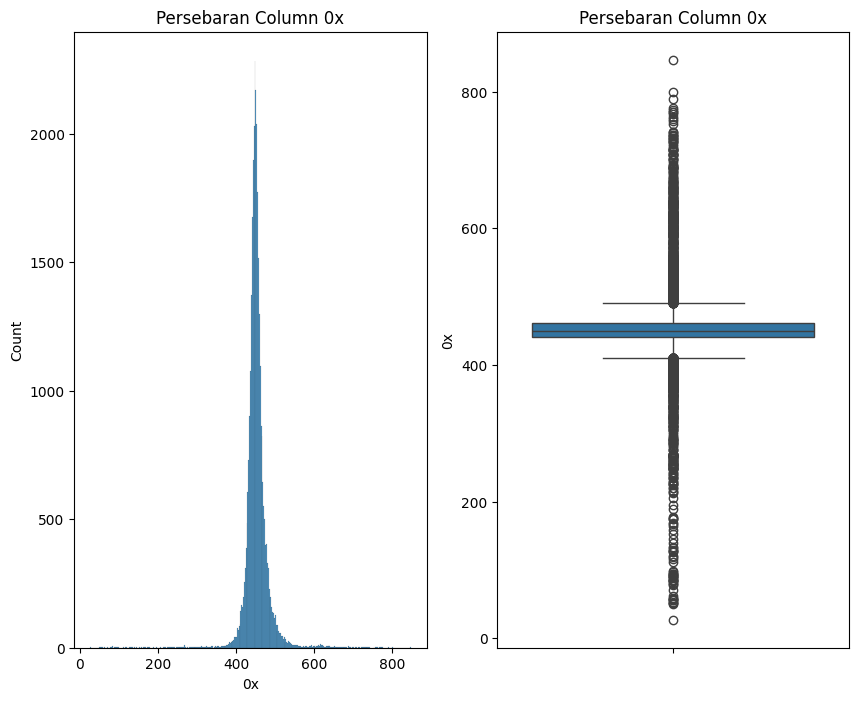

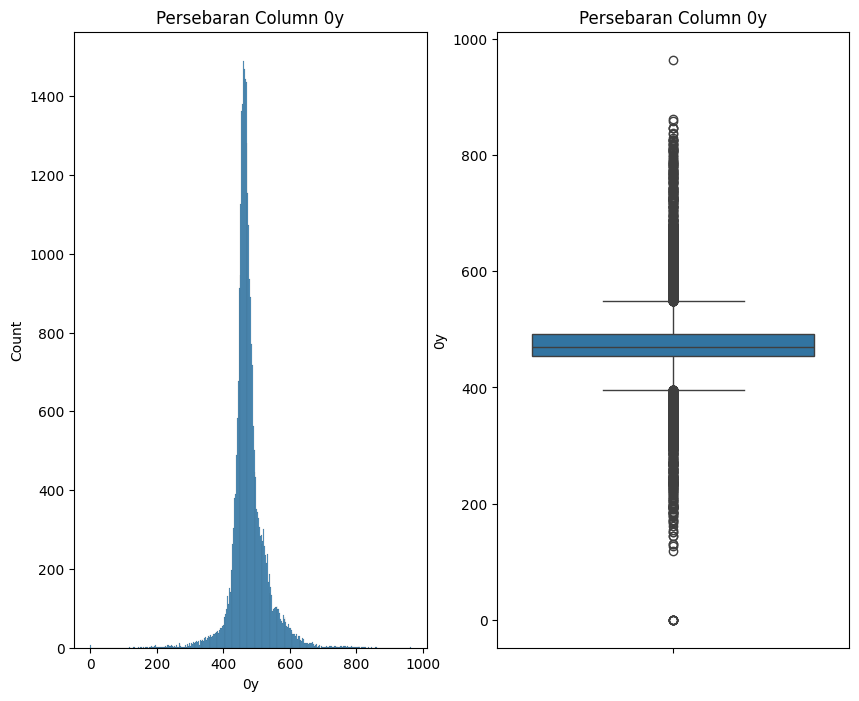

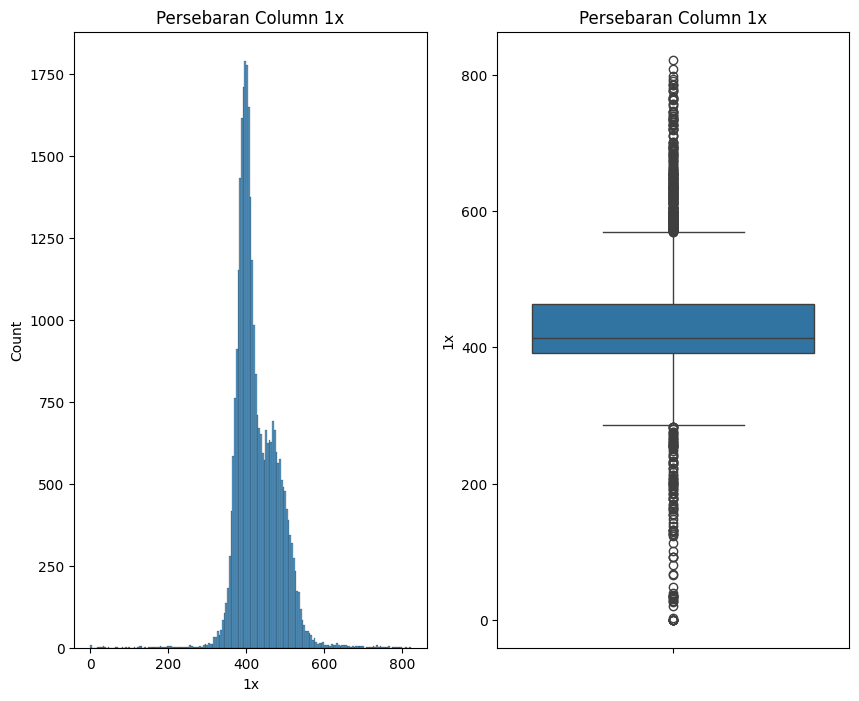

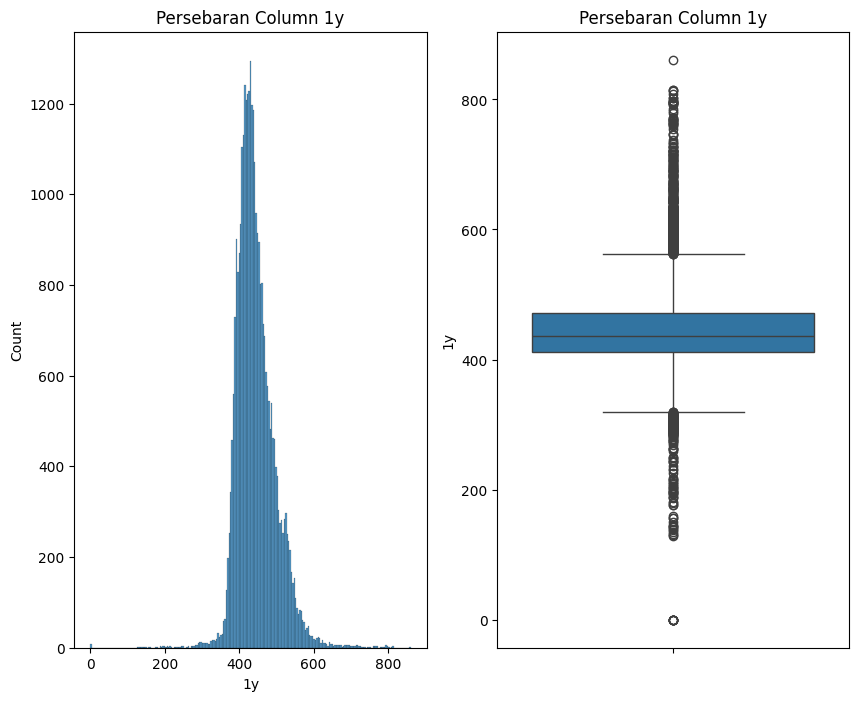

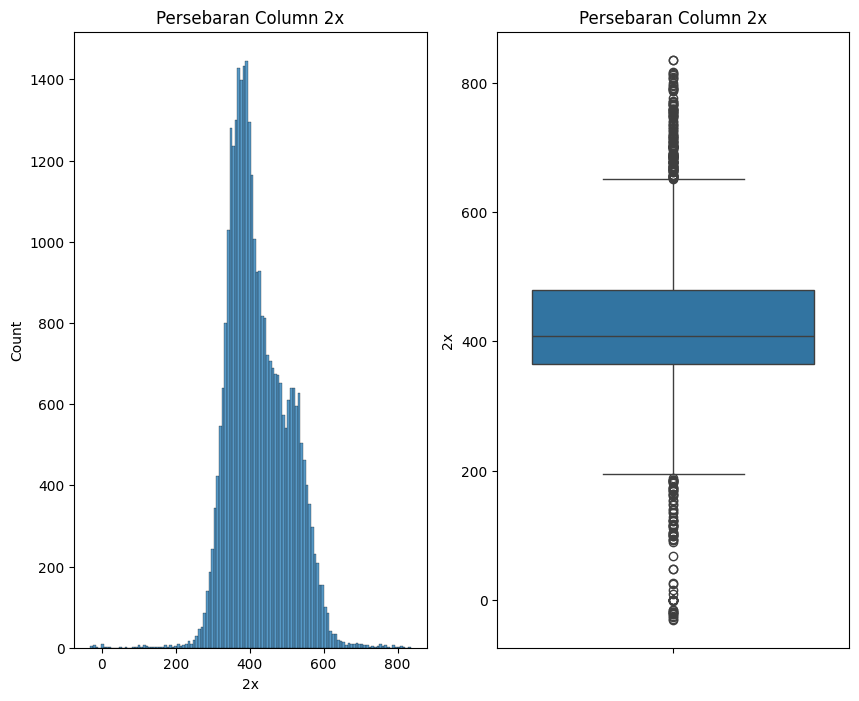

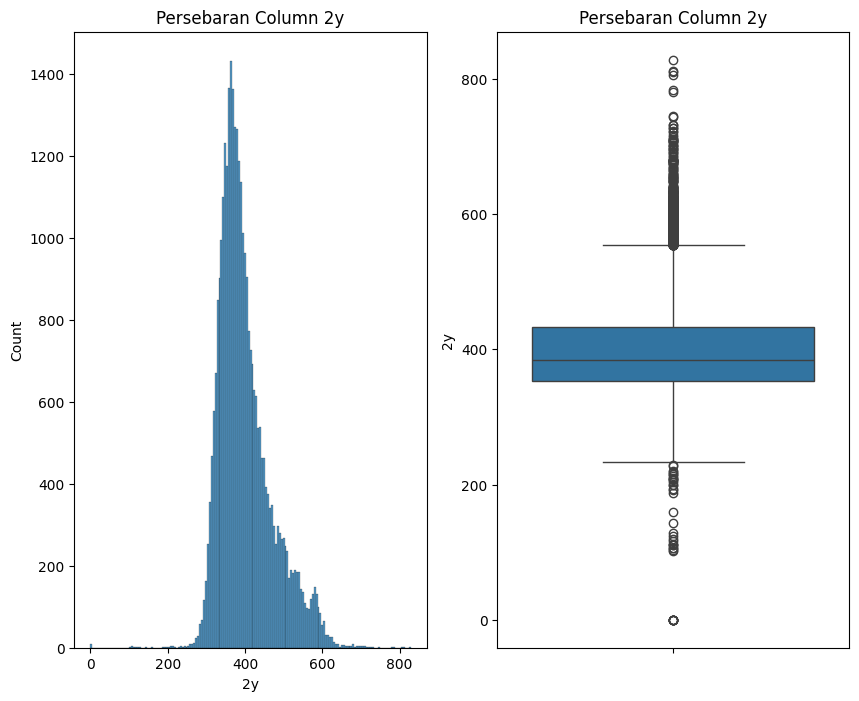

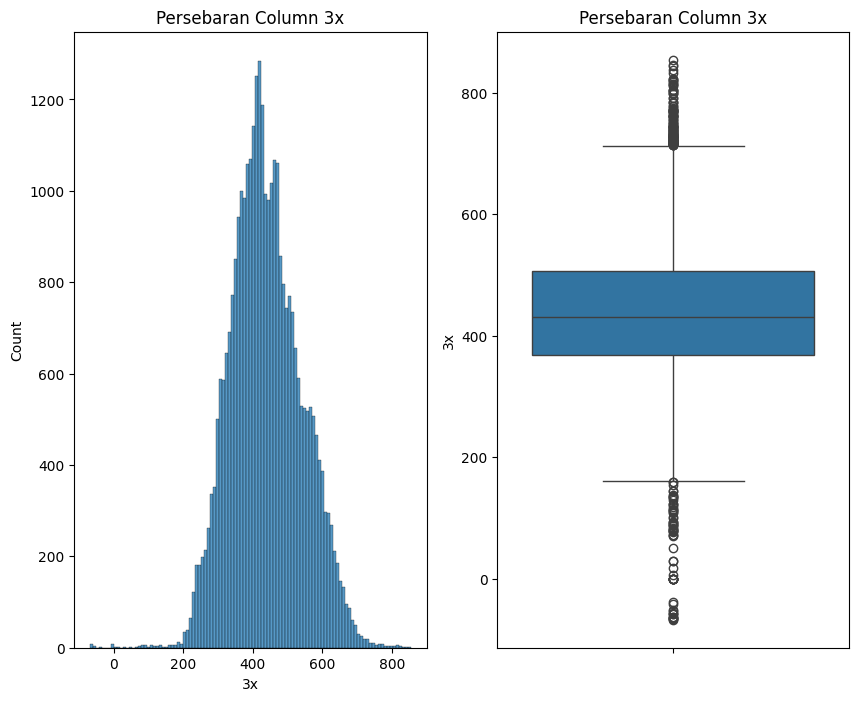

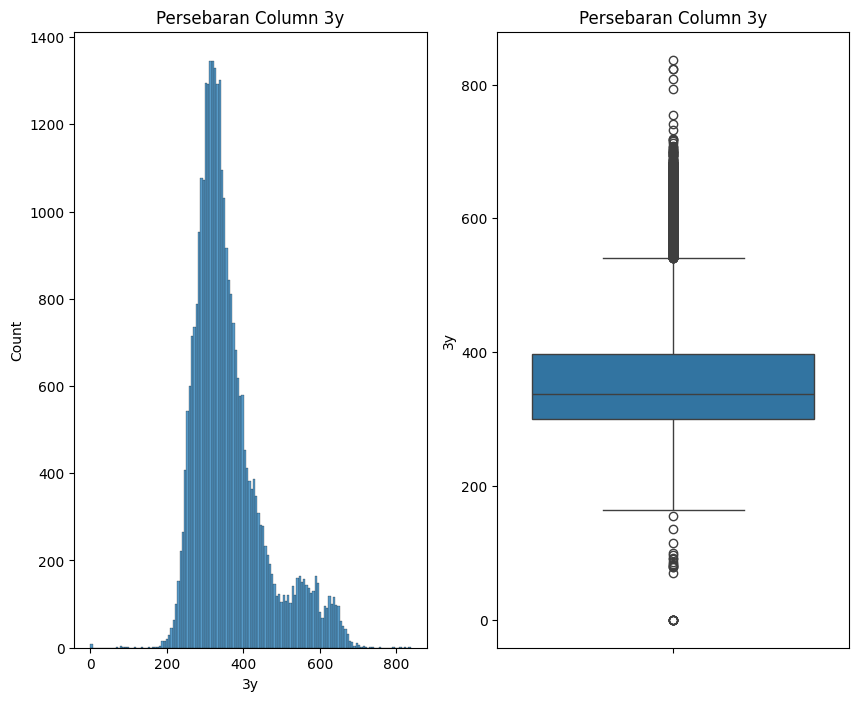

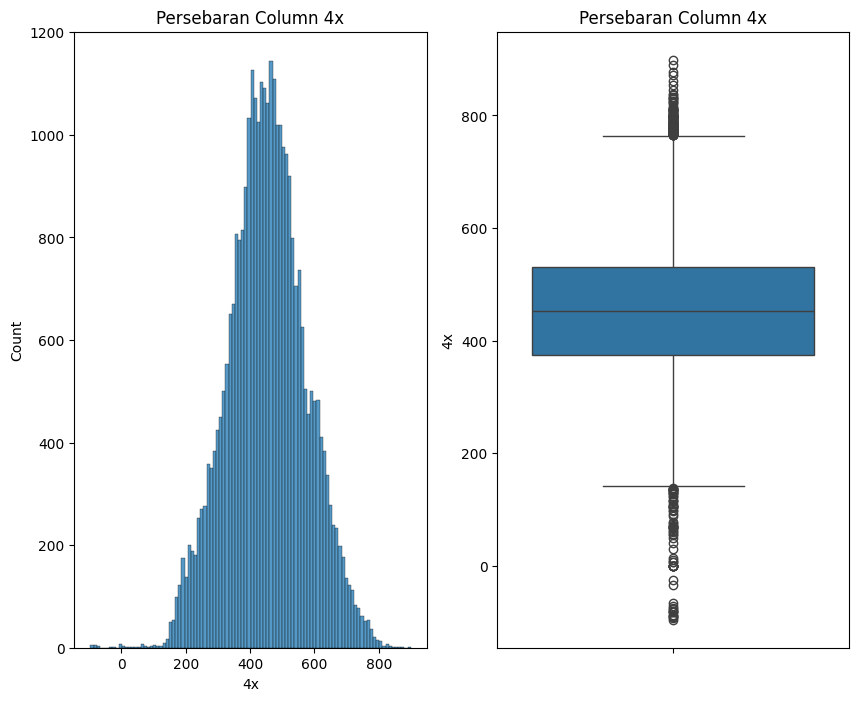

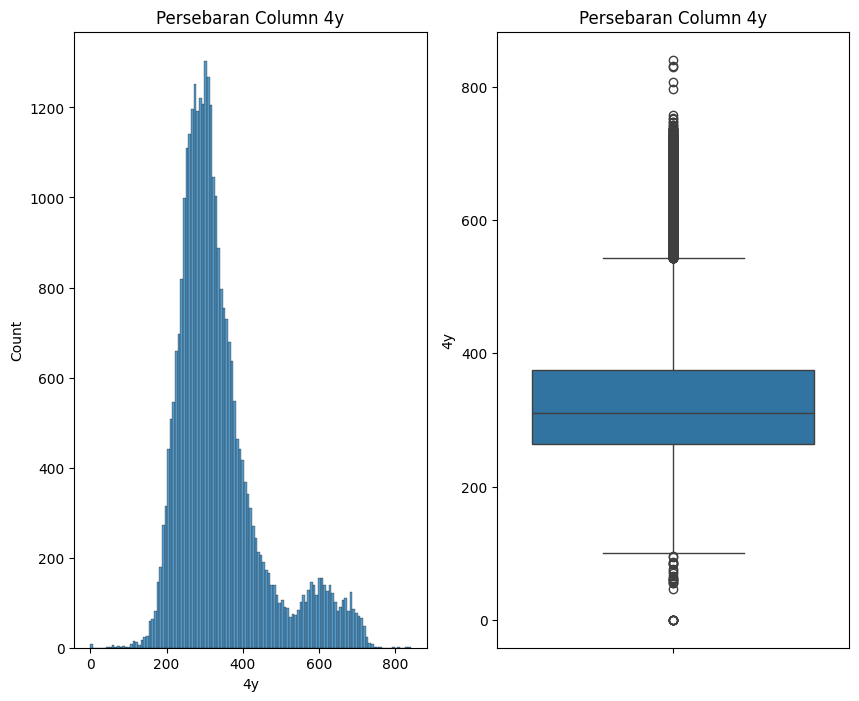

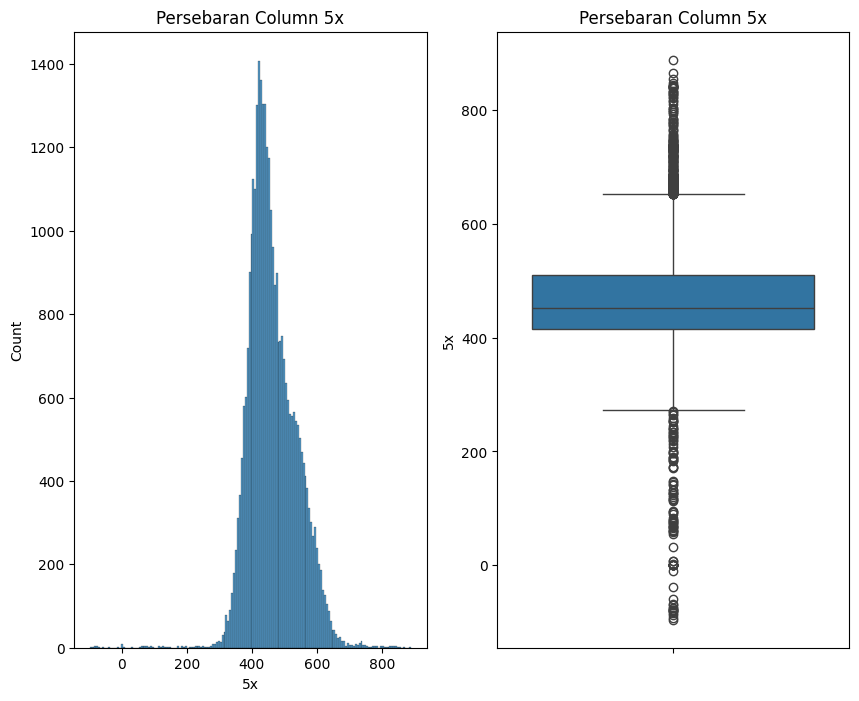

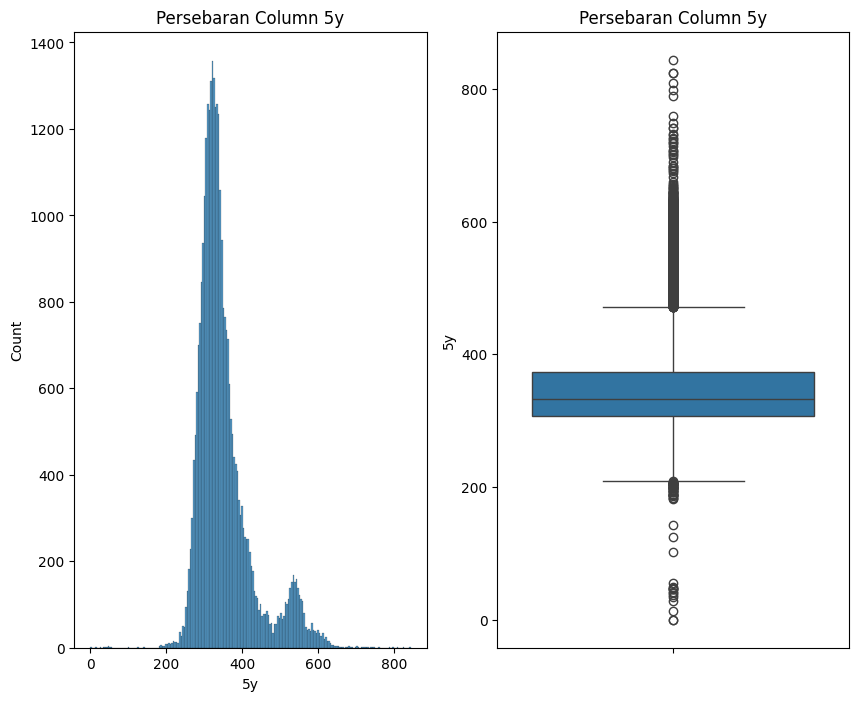

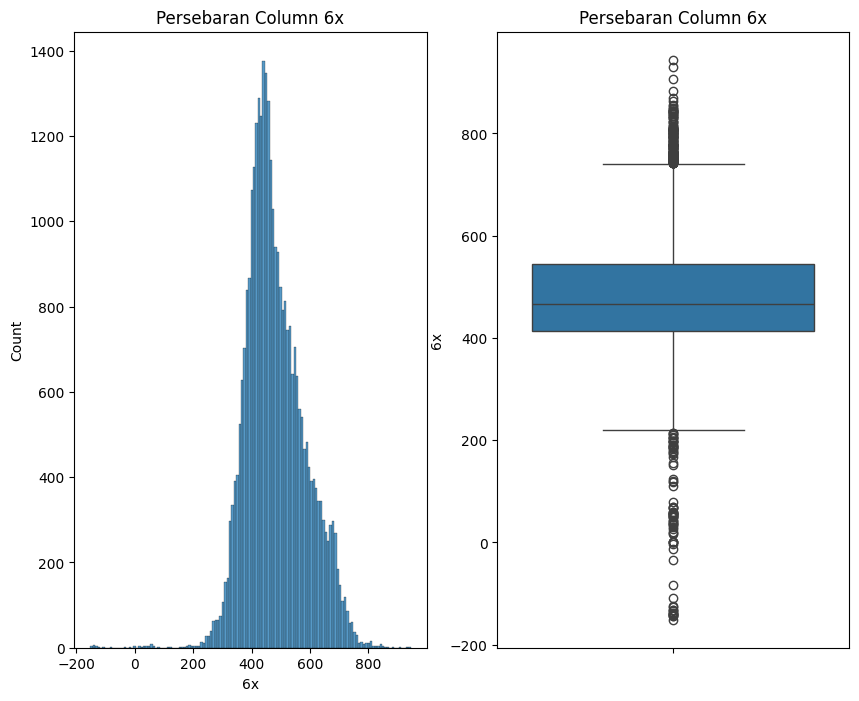

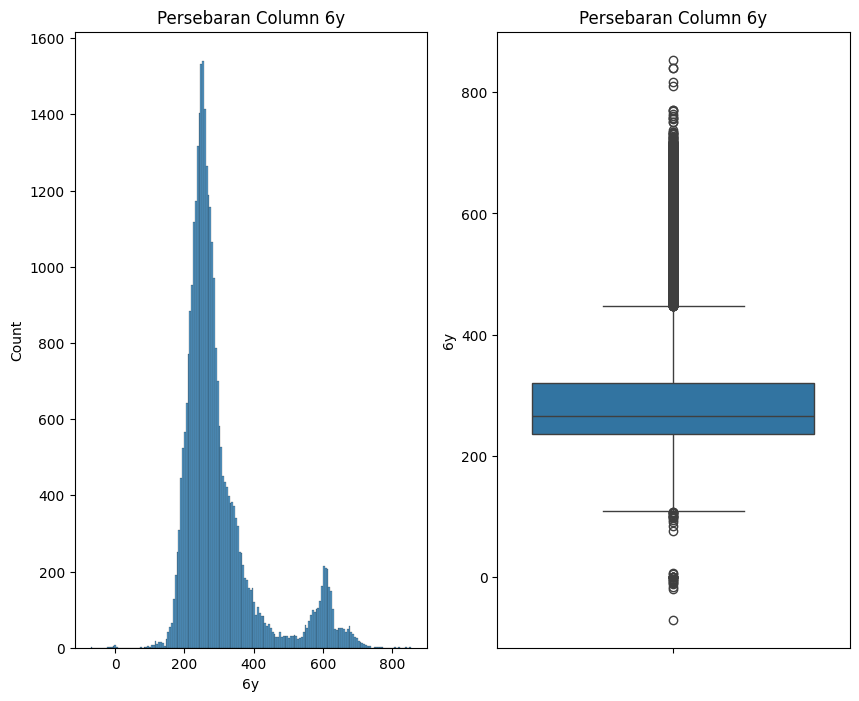

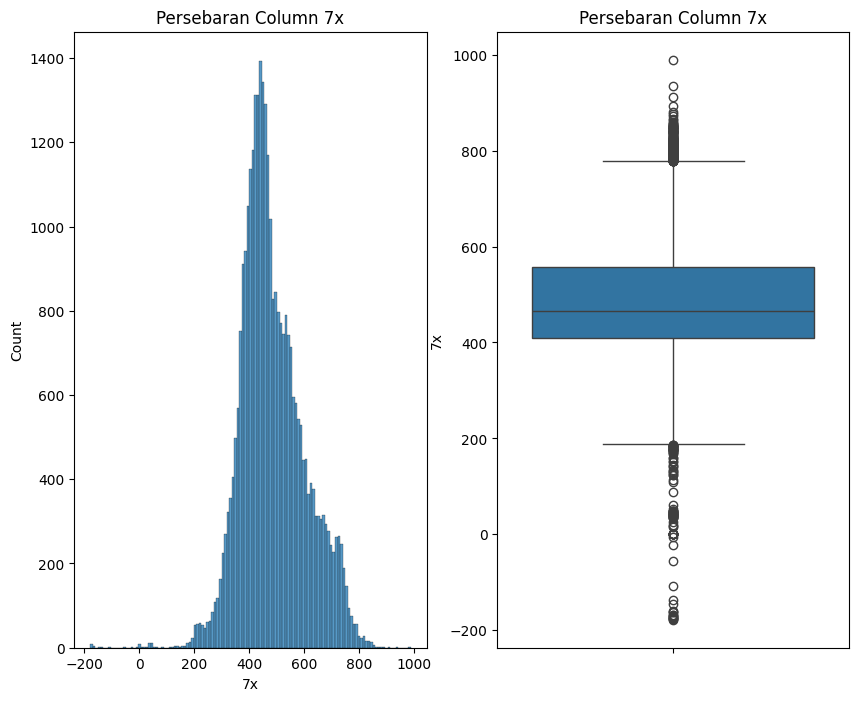

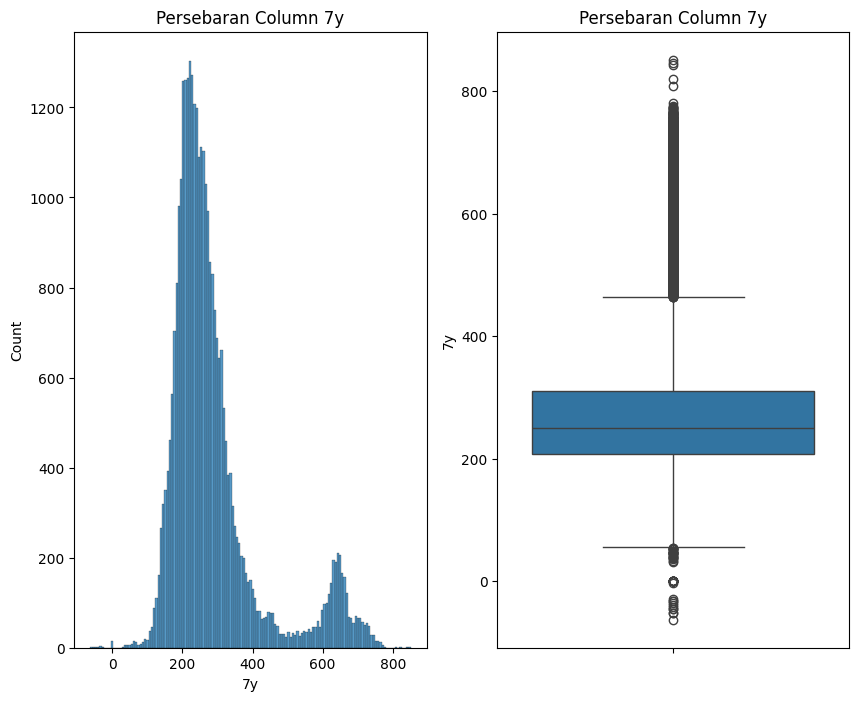

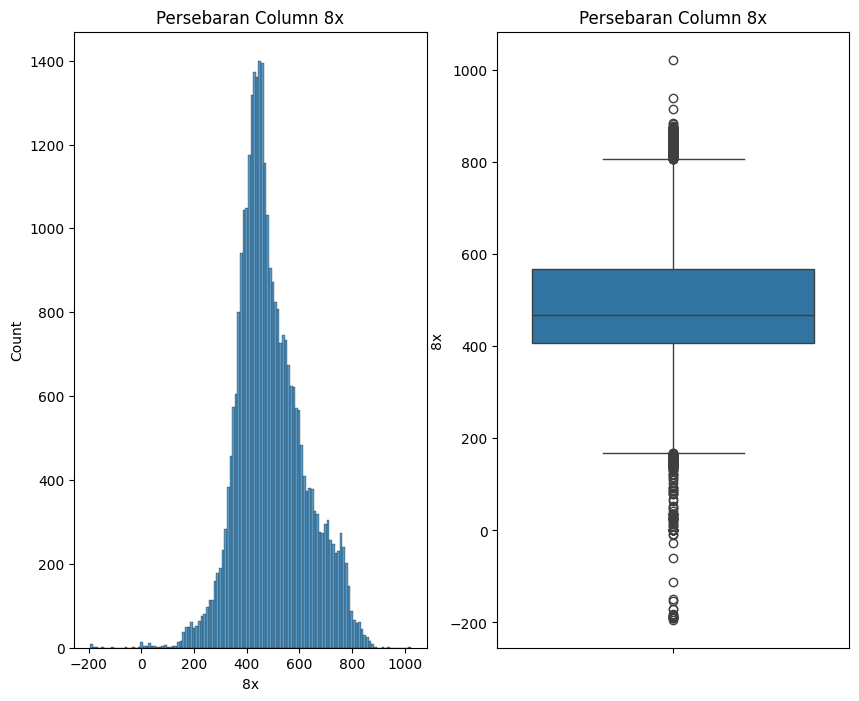

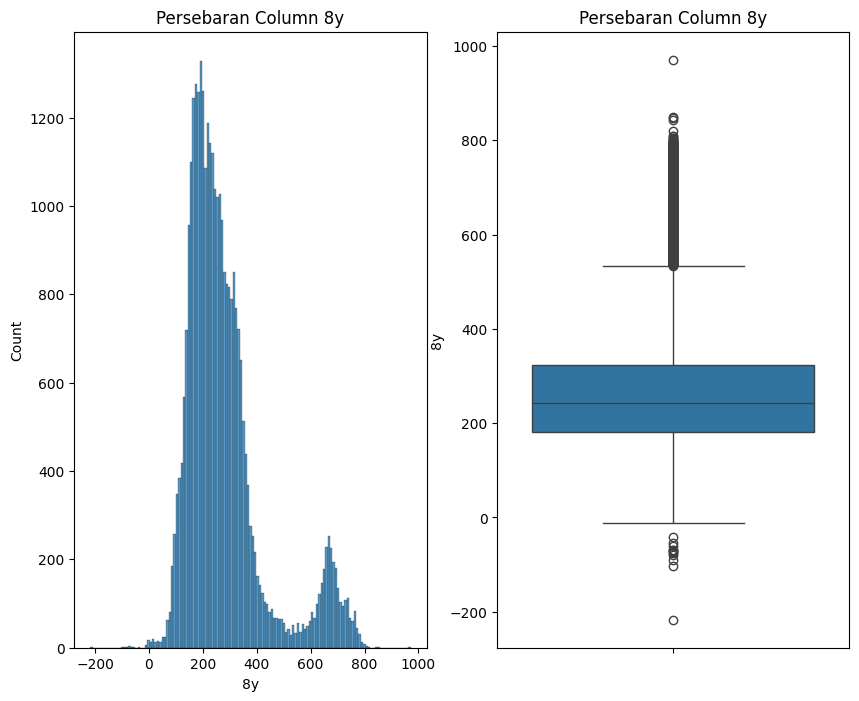

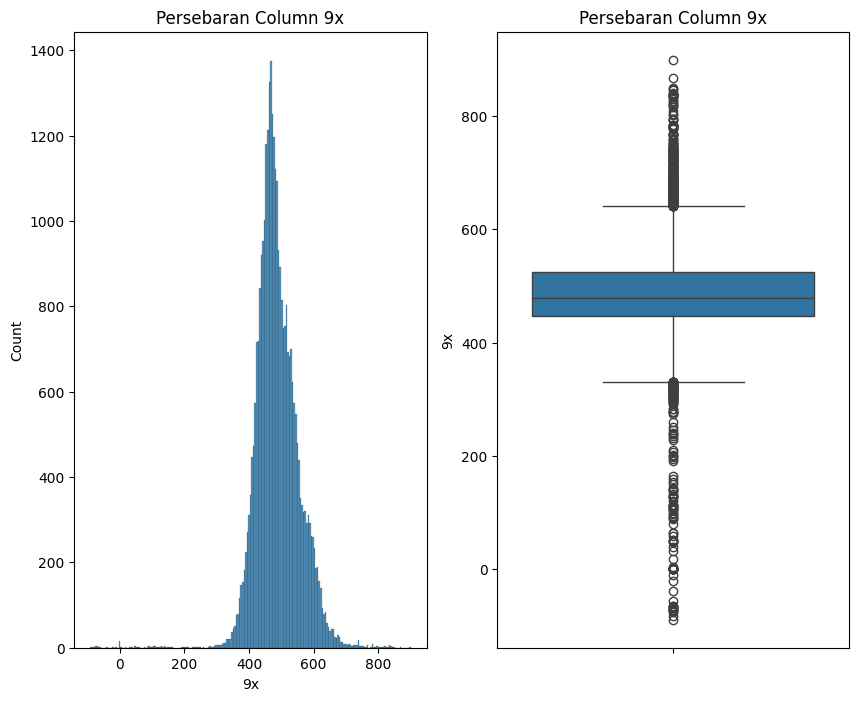

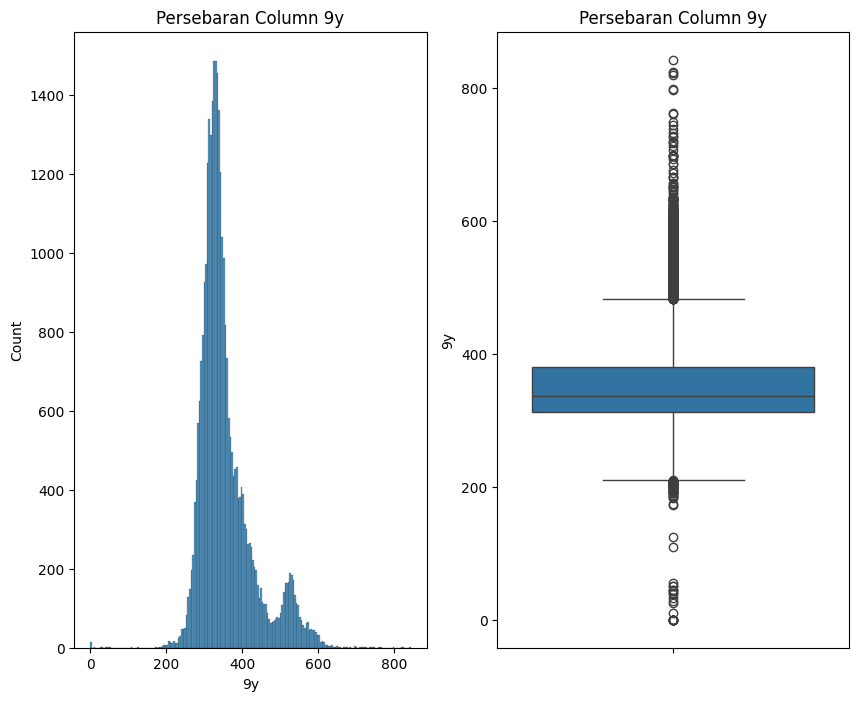

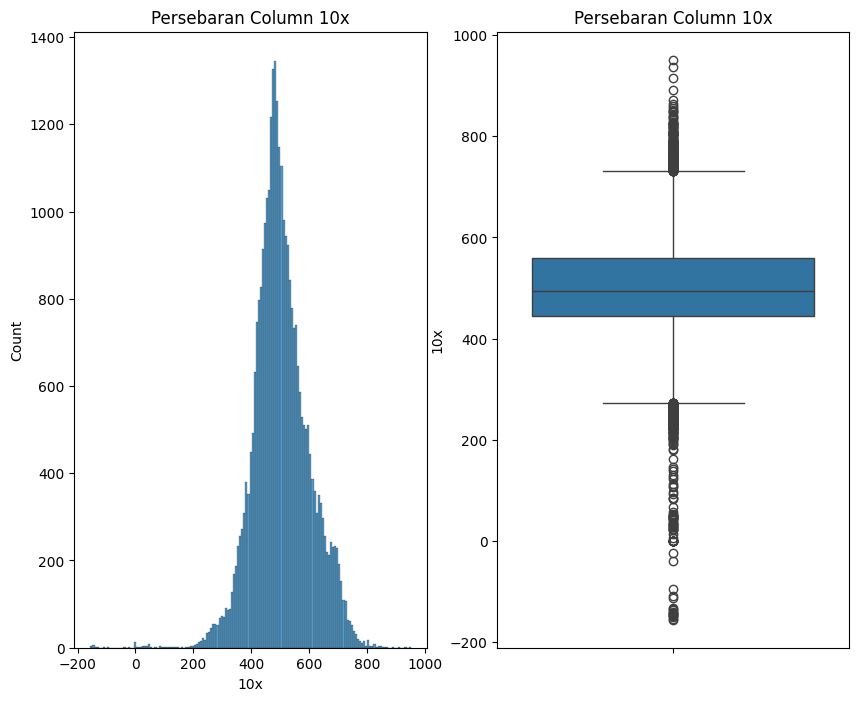

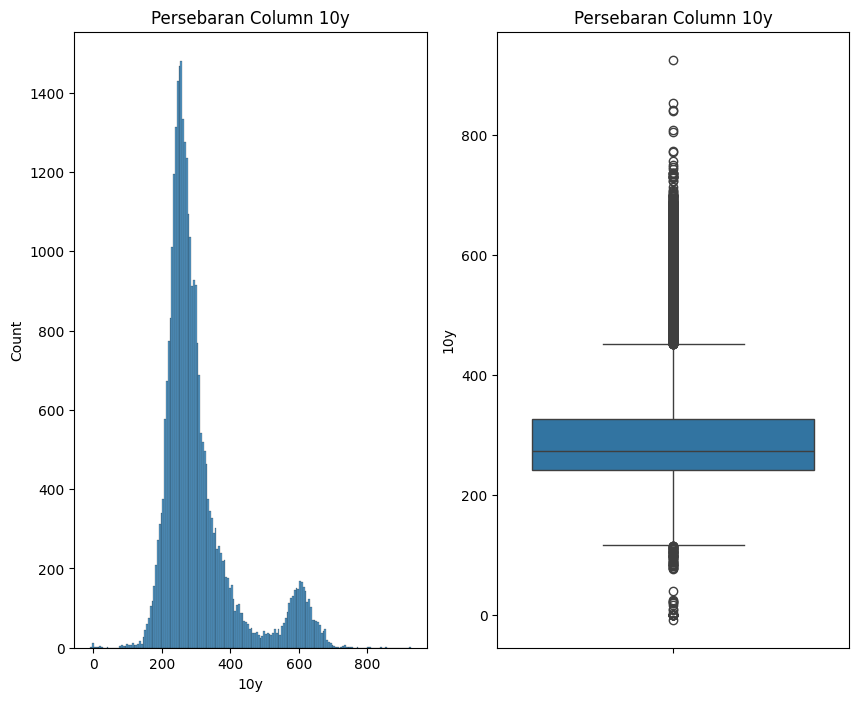

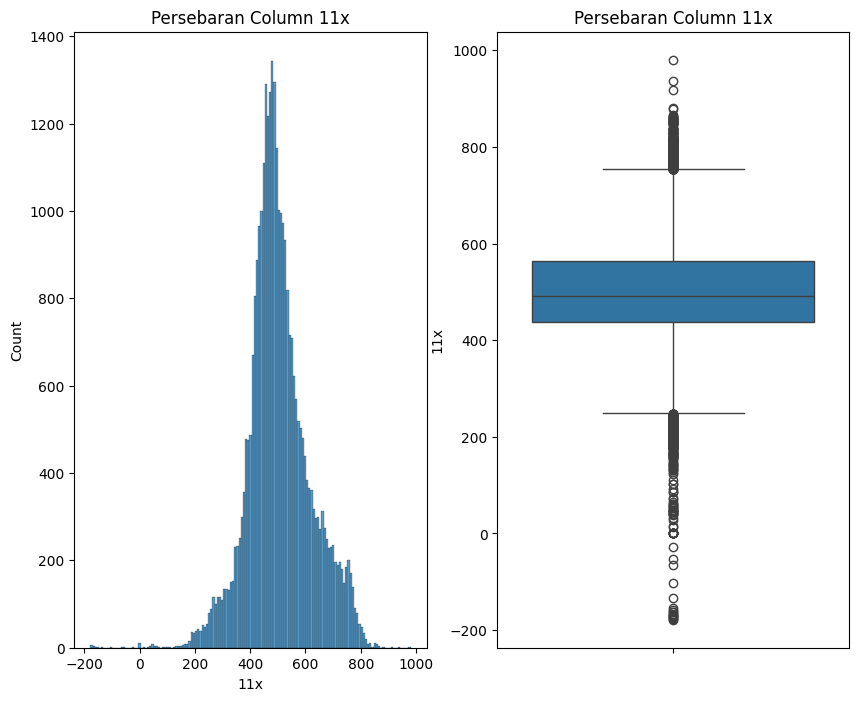

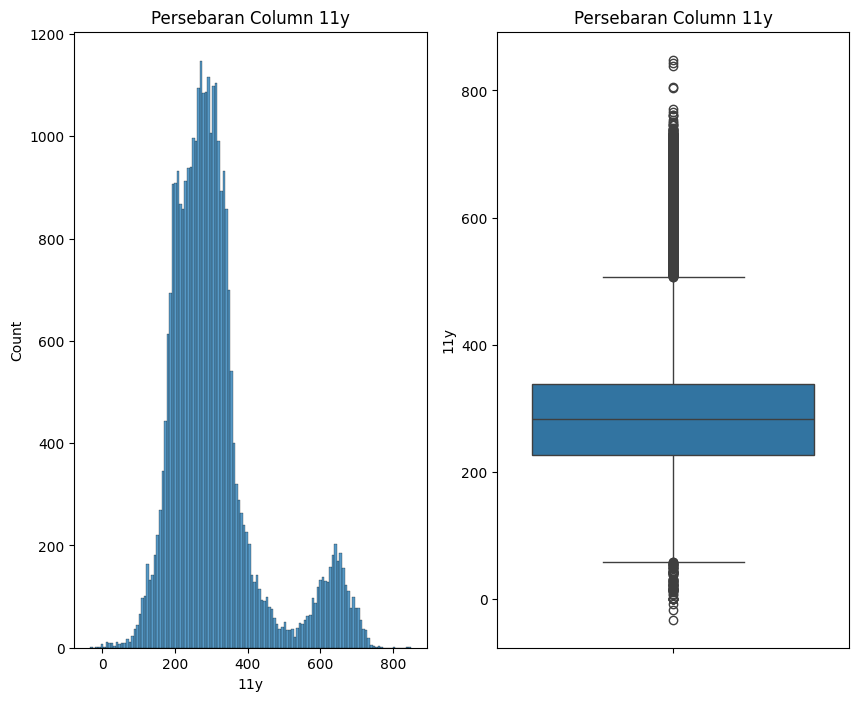

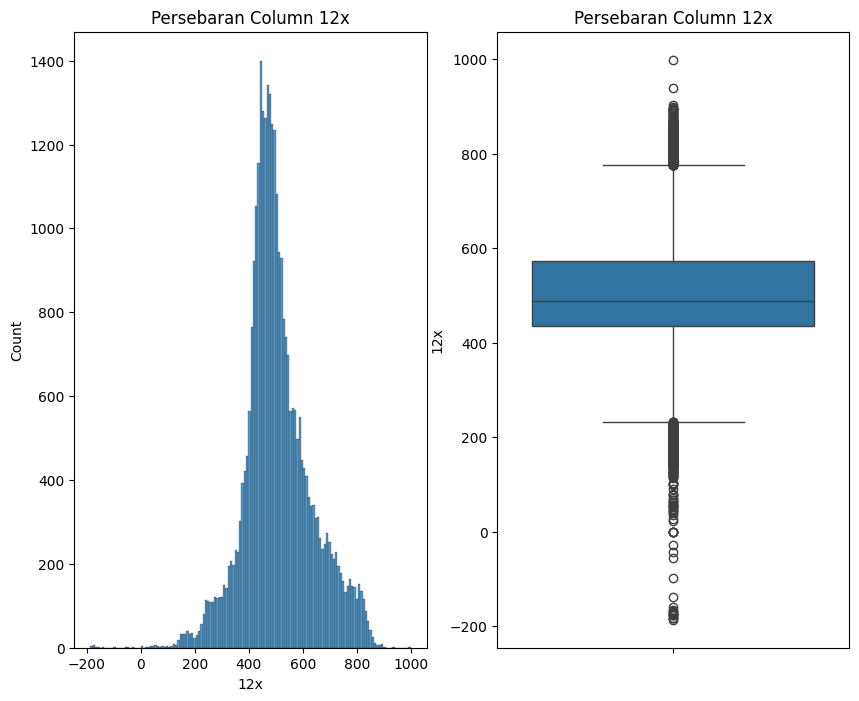

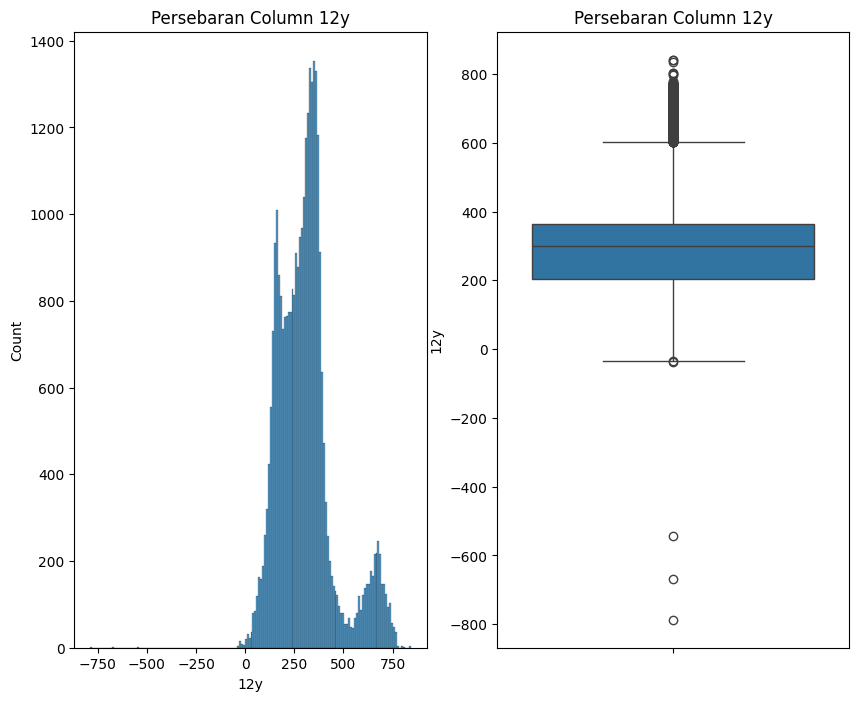

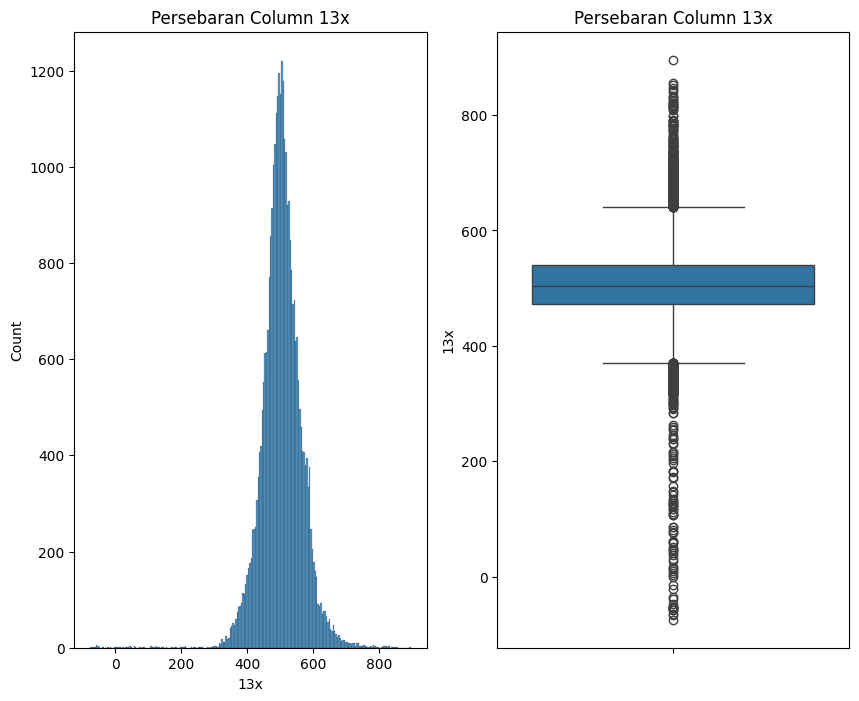

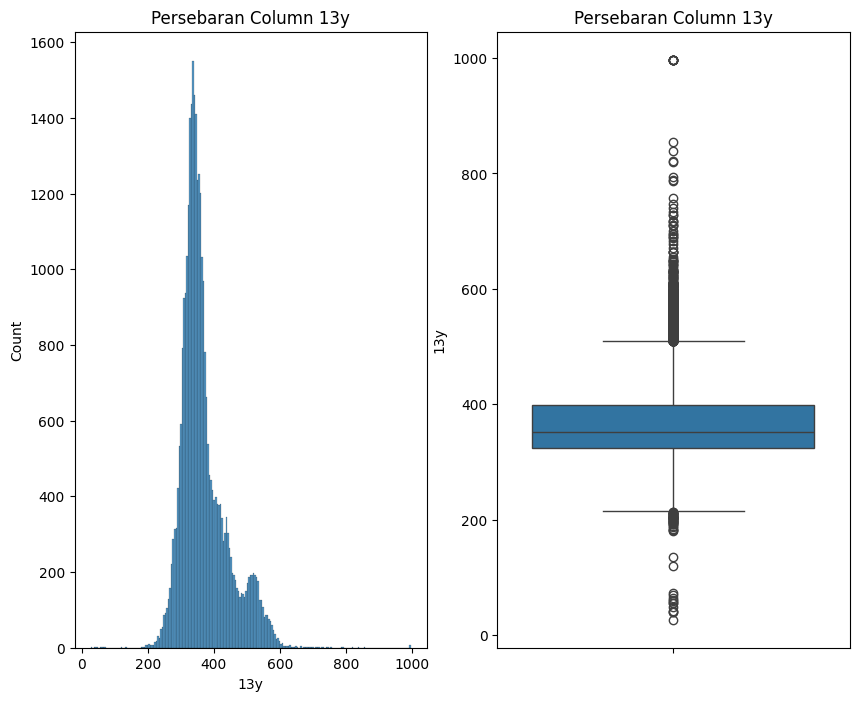

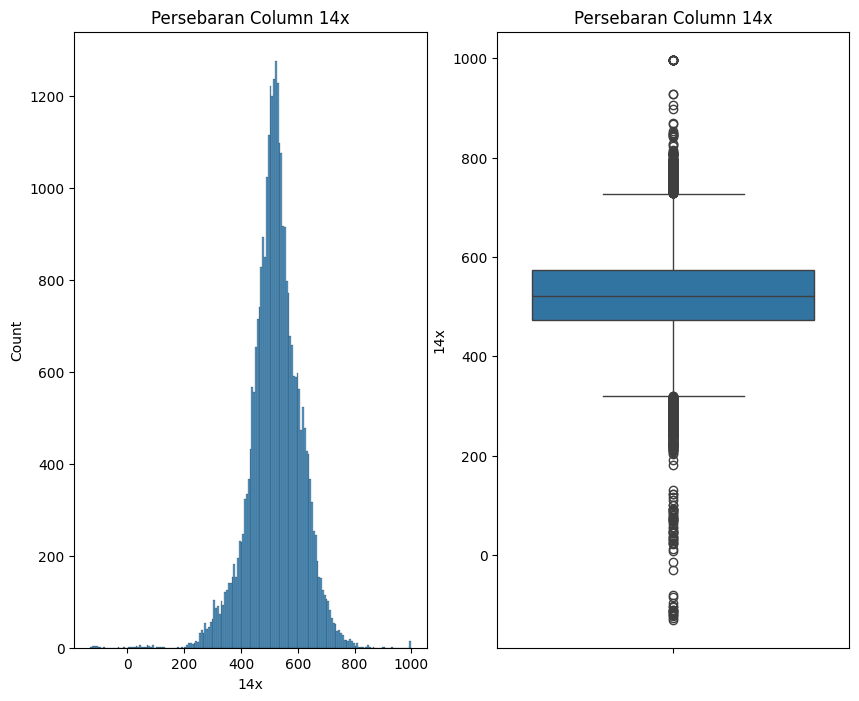

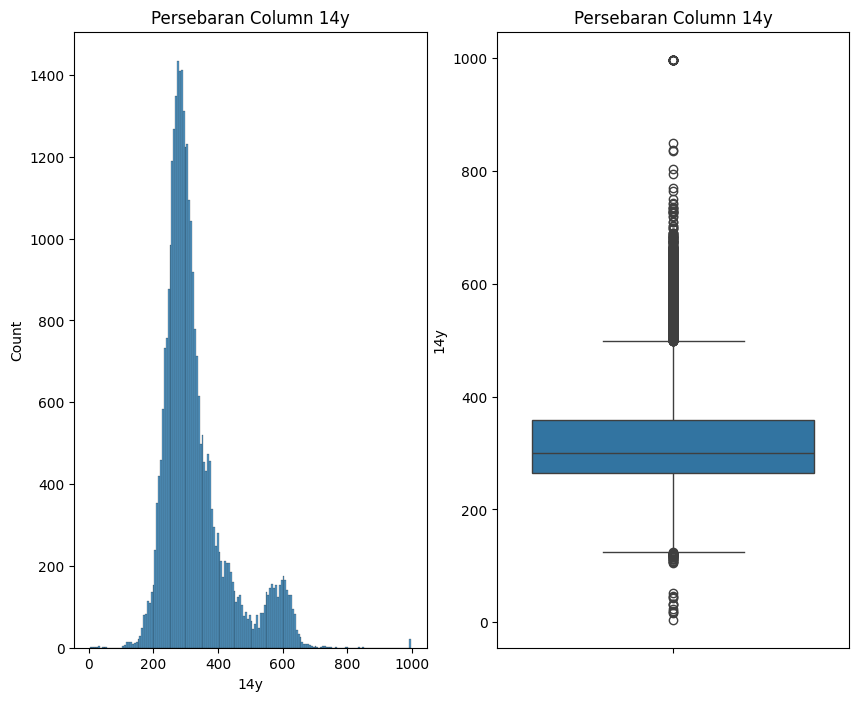

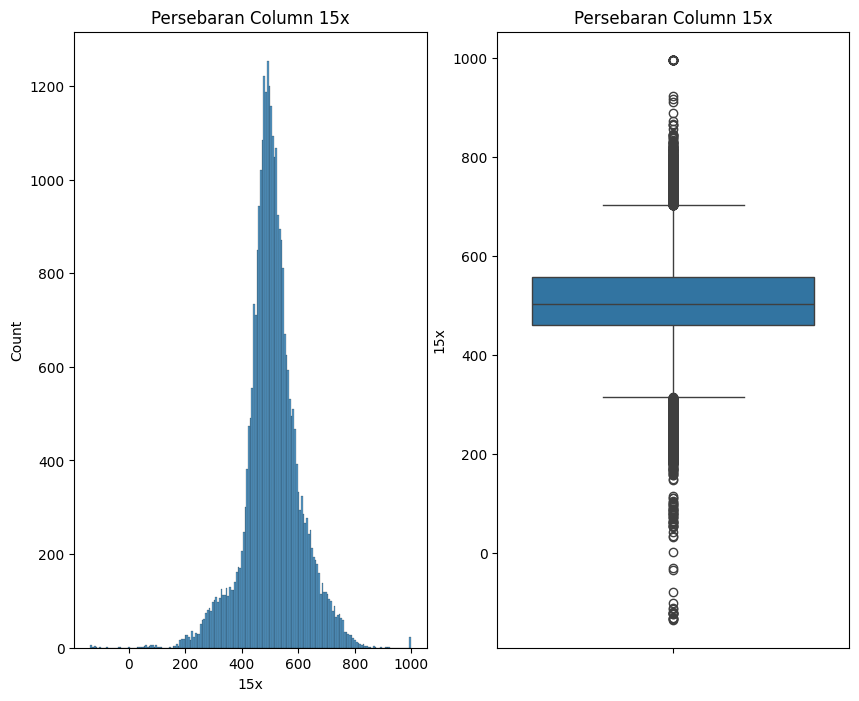

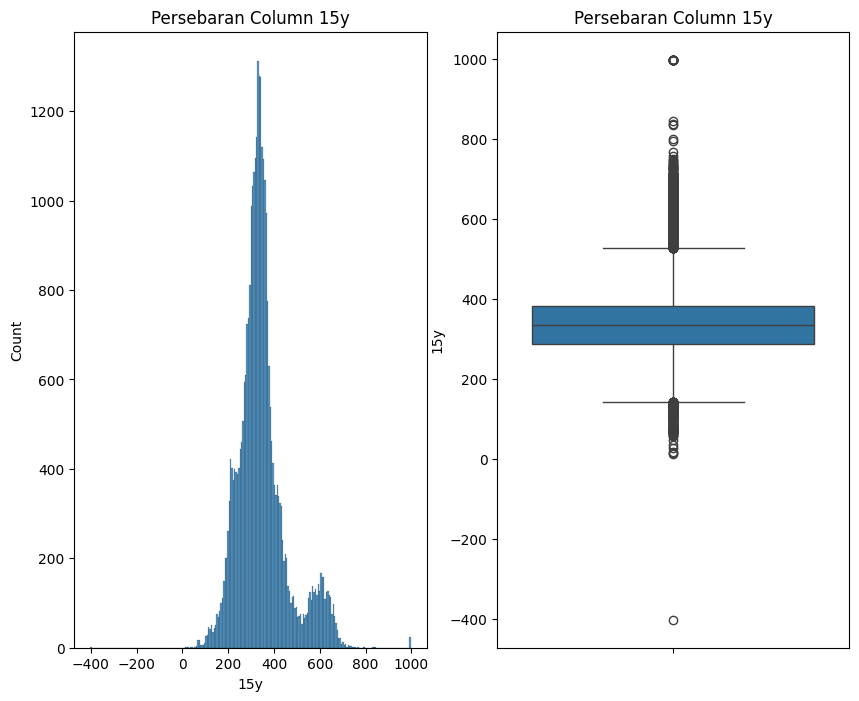

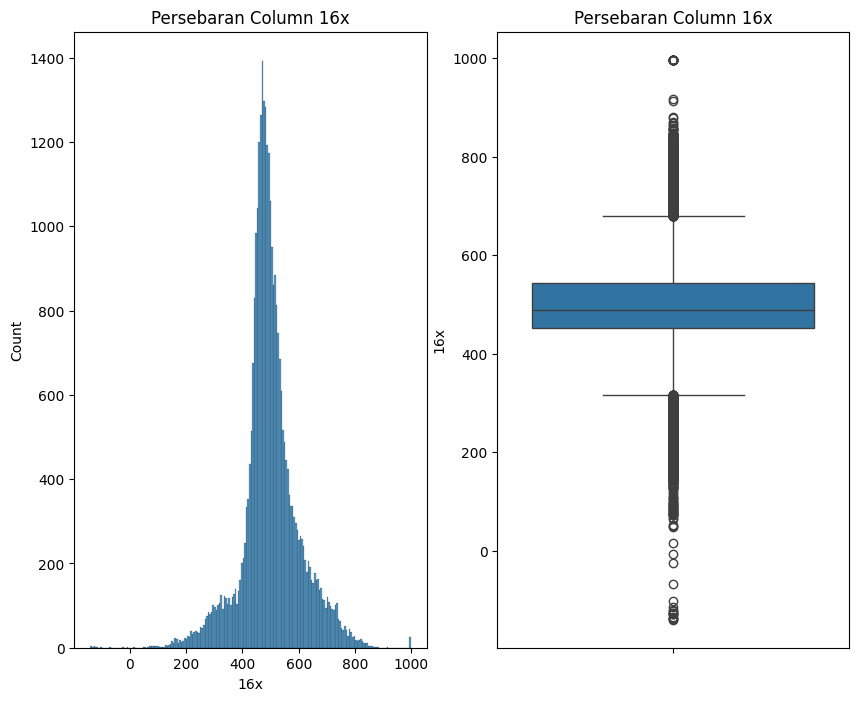

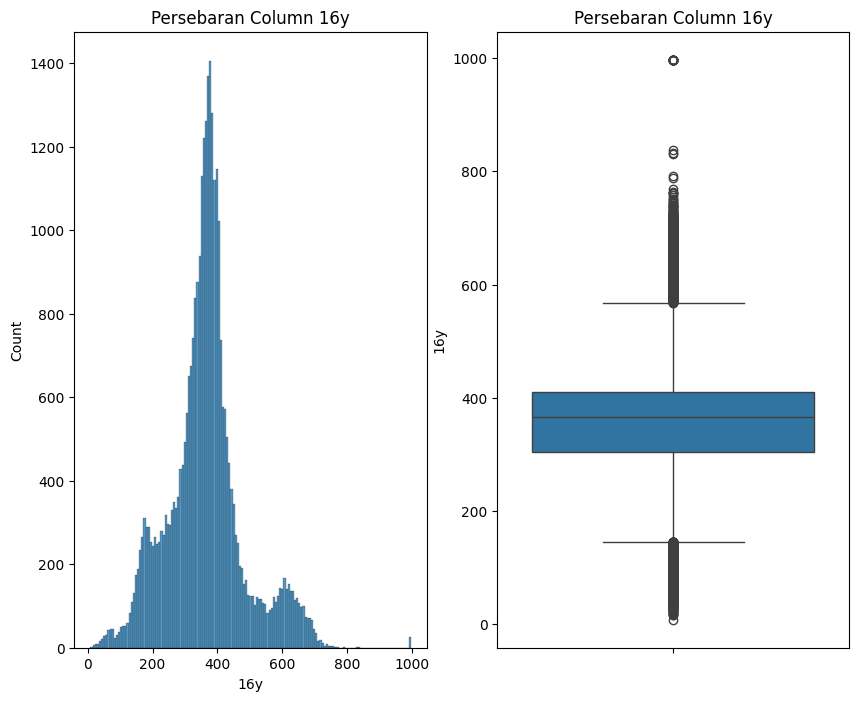

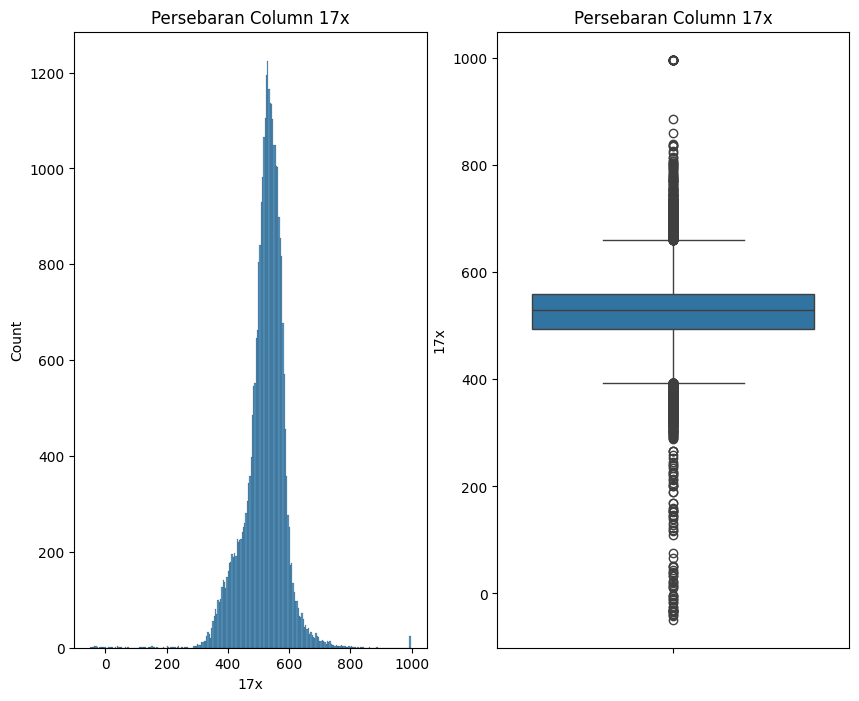

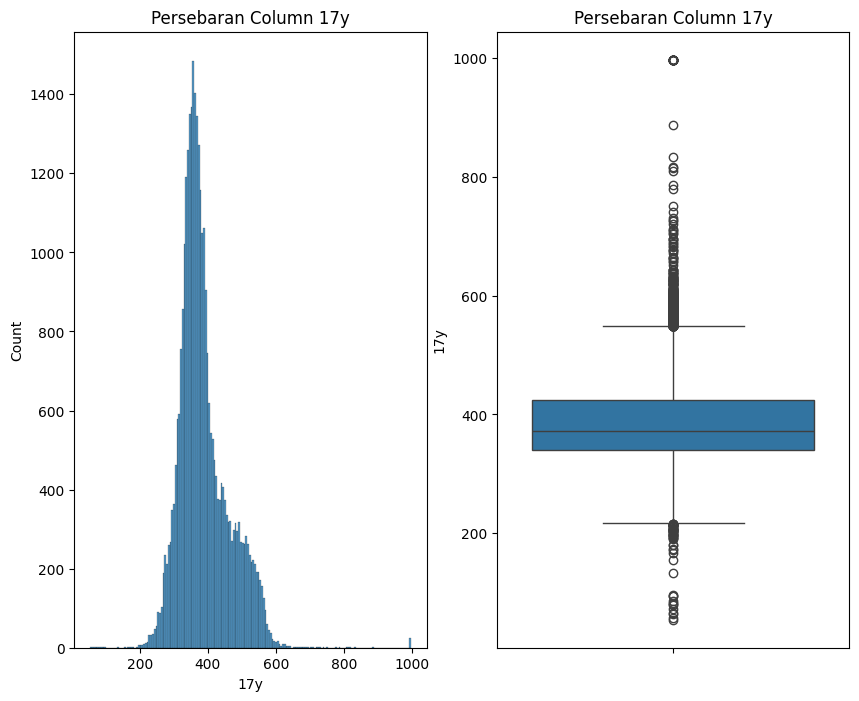

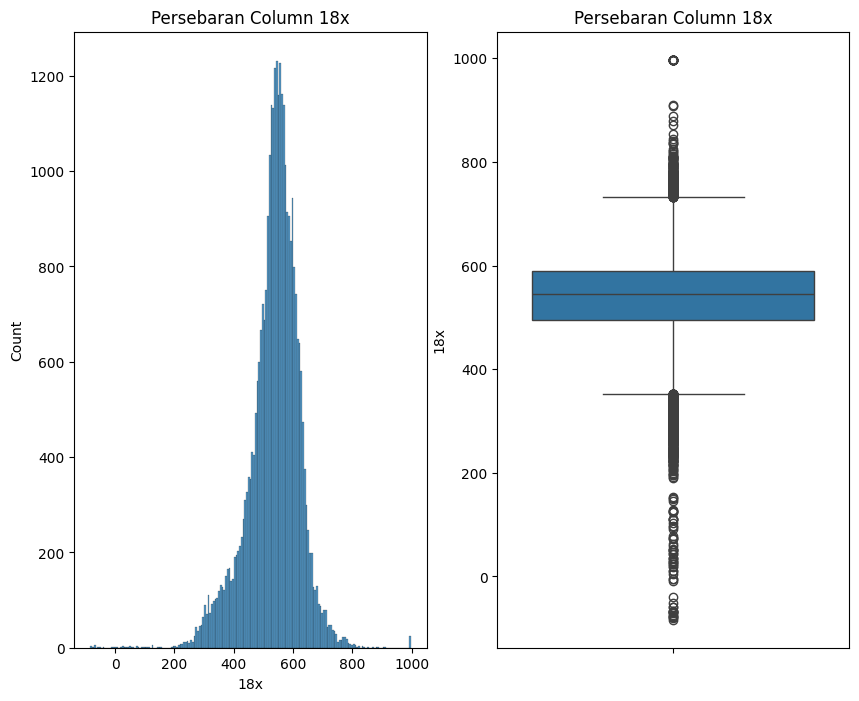

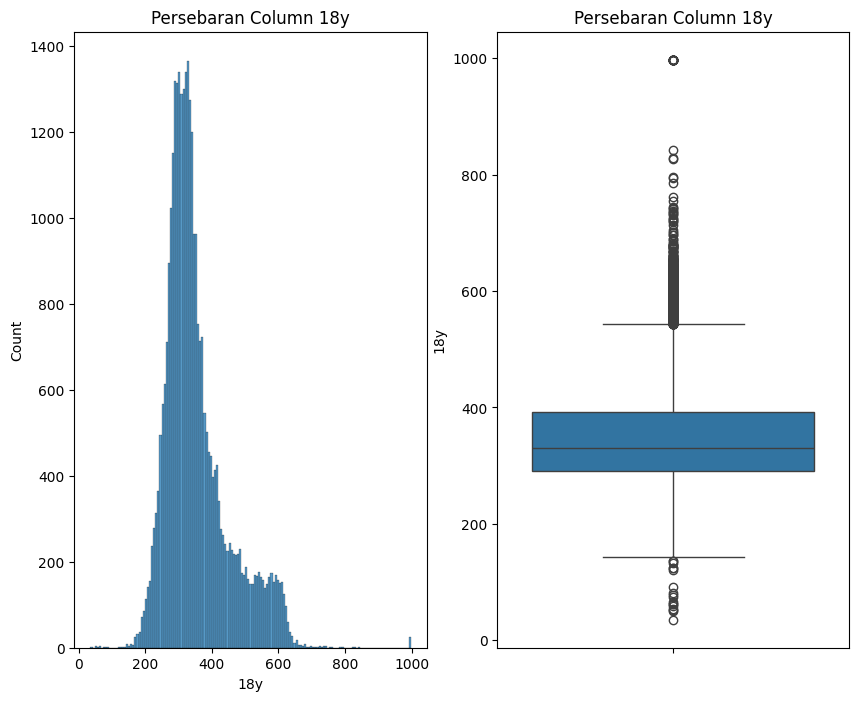

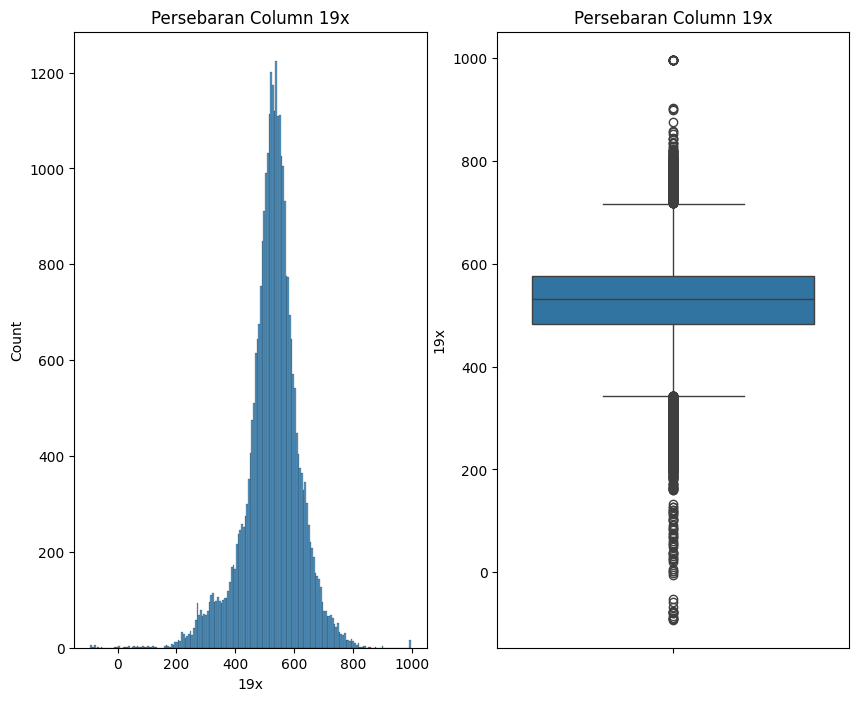

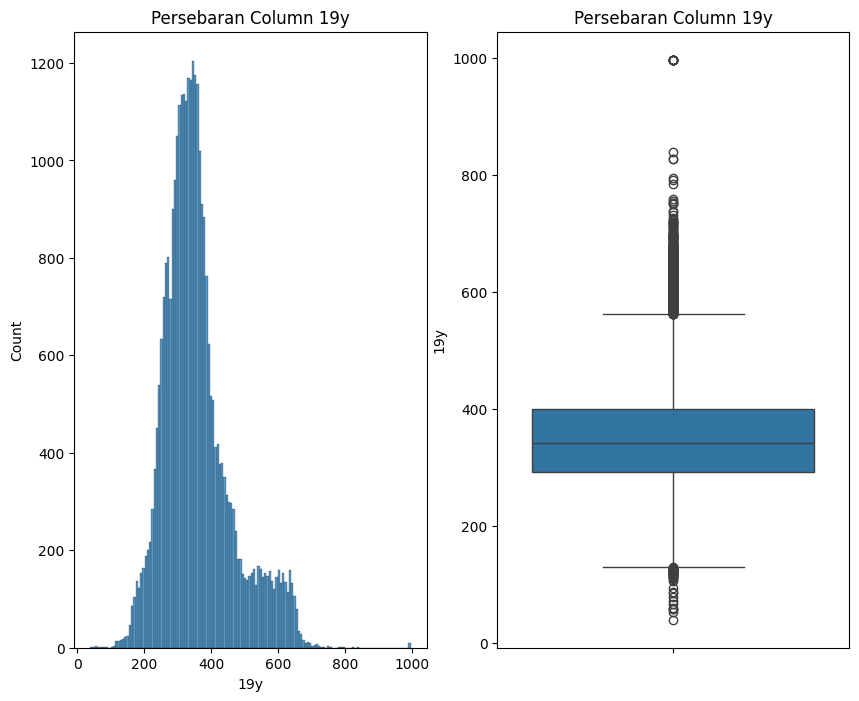

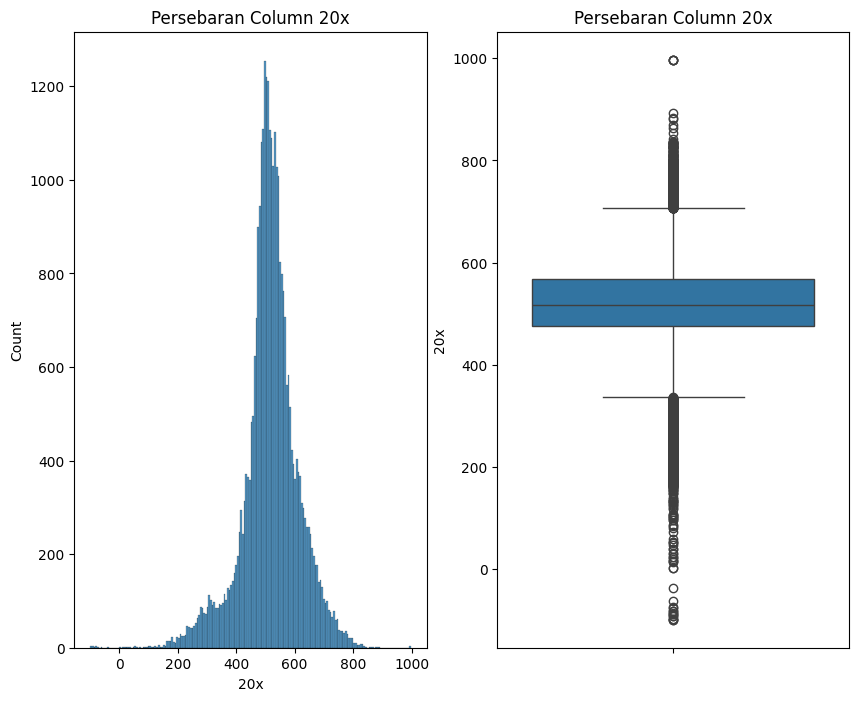

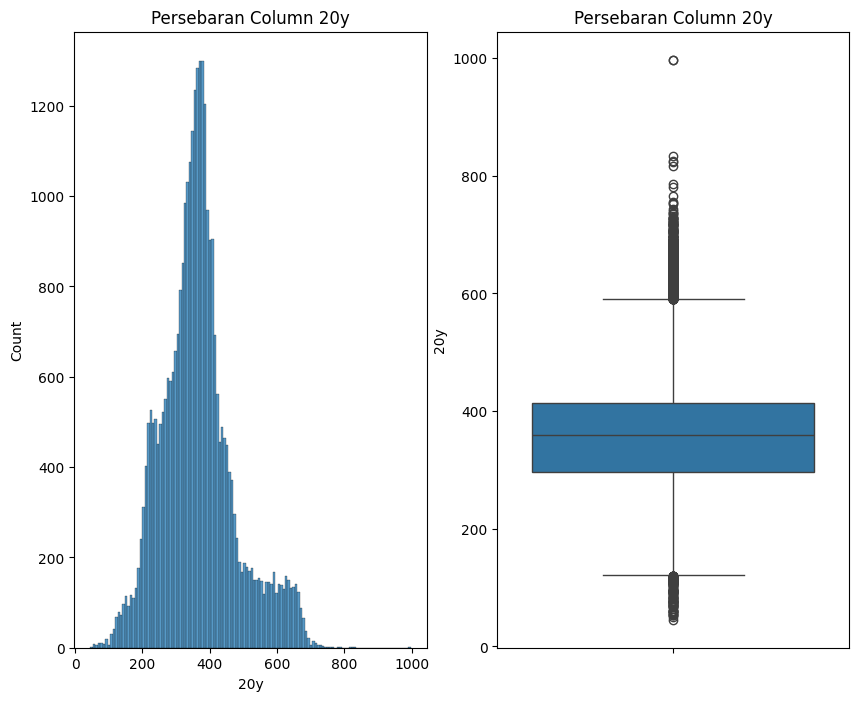

In [45]:
for col in df_train.select_dtypes(include='number'):
    fig, axes = plt.subplots(1, 2, figsize=(10, 8))
    
    sns.histplot(df_train[col], ax = axes[0])
    axes[0].set_title(f"Persebaran Column {col}")
    
    sns.boxplot(df_train[col], ax = axes[1])
    axes[1].set_title(f"Persebaran Column {col}")

## B. Data Preprocessing

### B.1 Label Encoding

In [46]:
char_mapping = {'A' : 0, 'B' : 1, 'C' : 2, 'D' : 3, 'E' : 4, 'F' : 5, 'G' : 6, 'H' : 7, 'I' : 8,
                'K' : 9, 'L' : 10, 'M' : 11, 'N' : 12, 'O' : 13, 'P' : 14, 'Q' : 15, 'R' : 16,
                'S' : 17, 'T' : 18, 'U' : 19, 'V' : 20, 'W' : 21, 'X' : 22, 'Y' : 23}

df_train['char'] = df_train['char'].map(char_mapping)
df_test['char'] = df_test['char'].map(char_mapping)

### B.2 Feature Engineering

#### Menggabungkan Fitur Yang Berkorelasi

In [47]:
# df_train['0xy'] = df_train['0x'] * df_train['0y']
# df_train['1xy'] = df_train['1x'] * df_train['1y']
# df_train['2xy'] = df_train['2x'] * df_train['2y']
# df_train['3xy'] = df_train['3x'] * df_train['3y']
# df_train['4xy'] = df_train['4x'] * df_train['4y']
# df_train['5xy'] = df_train['5x'] * df_train['5y']
# df_train['6xy'] = df_train['6x'] * df_train['6y']
# df_train['7xy'] = df_train['7x'] * df_train['7y']
# df_train['8xy'] = df_train['8x'] * df_train['8y']
# df_train['9xy'] = df_train['9x'] * df_train['9y']
# df_train['10xy'] = df_train['10x'] * df_train['10y']
# df_train['11xy'] = df_train['11x'] * df_train['11y']
# df_train['12xy'] = df_train['12x'] * df_train['12y']
# df_train['13xy'] = df_train['13x'] * df_train['13y']
# df_train['14xy'] = df_train['14x'] * df_train['14y']
# df_train['15xy'] = df_train['15x'] * df_train['15y']
# df_train['16xy'] = df_train['16x'] * df_train['16y']
# df_train['17xy'] = df_train['17x'] * df_train['17y']
# df_train['18xy'] = df_train['18x'] * df_train['18y']
# df_train['19xy'] = df_train['19x'] * df_train['19y']
# df_train['20xy'] = df_train['20x'] * df_train['20y']

In [48]:
# df_test['0xy'] = df_test['0x'] * df_test['0y']
# df_test['1xy'] = df_test['1x'] * df_test['1y']
# df_test['2xy'] = df_test['2x'] * df_test['2y']
# df_test['3xy'] = df_test['3x'] * df_test['3y']
# df_test['4xy'] = df_test['4x'] * df_test['4y']
# df_test['5xy'] = df_test['5x'] * df_test['5y']
# df_test['6xy'] = df_test['6x'] * df_test['6y']
# df_test['7xy'] = df_test['7x'] * df_test['7y']
# df_test['8xy'] = df_test['8x'] * df_test['8y']
# df_test['9xy'] = df_test['9x'] * df_test['9y']
# df_test['10xy'] = df_test['10x'] * df_test['10y']
# df_test['11xy'] = df_test['11x'] * df_test['11y']
# df_test['12xy'] = df_test['12x'] * df_test['12y']
# df_test['13xy'] = df_test['13x'] * df_test['13y']
# df_test['14xy'] = df_test['14x'] * df_test['14y']
# df_test['15xy'] = df_test['15x'] * df_test['15y']
# df_test['16xy'] = df_test['16x'] * df_test['16y']
# df_test['17xy'] = df_test['17x'] * df_test['17y']
# df_test['18xy'] = df_test['18x'] * df_test['18y']
# df_test['19xy'] = df_test['19x'] * df_test['19y']
# df_test['20xy'] = df_test['20x'] * df_test['20y']

#### Drop Fitur Awal

In [49]:
# df_train = df_train.drop(columns=['0x', '0y', '1x', '1y', '2x', '2y', '3x', '3y', '4x', '4y', '5x', '5y',
#        '6x', '6y', '7x', '7y', '8x', '8y', '9x', '9y', '10x', '10y', '11x',
#        '11y', '12x', '12y', '13x', '13y', '14x', '14y', '15x', '15y', '16x',
#        '16y', '17x', '17y', '18x', '18y', '19x', '19y', '20x', '20y'])

In [50]:
# df_test = df_test.drop(columns=['0x', '0y', '1x', '1y', '2x', '2y', '3x', '3y', '4x', '4y', '5x', '5y',
#        '6x', '6y', '7x', '7y', '8x', '8y', '9x', '9y', '10x', '10y', '11x',
#        '11y', '12x', '12y', '13x', '13y', '14x', '14y', '15x', '15y', '16x',
#        '16y', '17x', '17y', '18x', '18y', '19x', '19y', '20x', '20y'])

<Axes: >

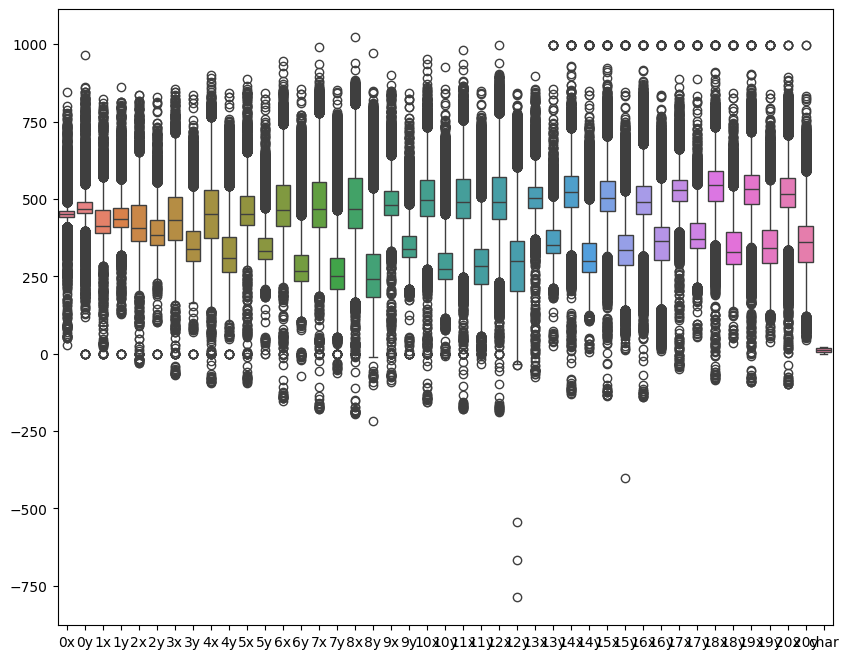

In [51]:
plt.figure(figsize=(10, 8))
sns.boxplot(df_train)

## C. Explotatory Data Analysis (EDA)

### C.1 Univariate Analysis

Text(0.5, 1.0, 'Persebaran Columns Target')

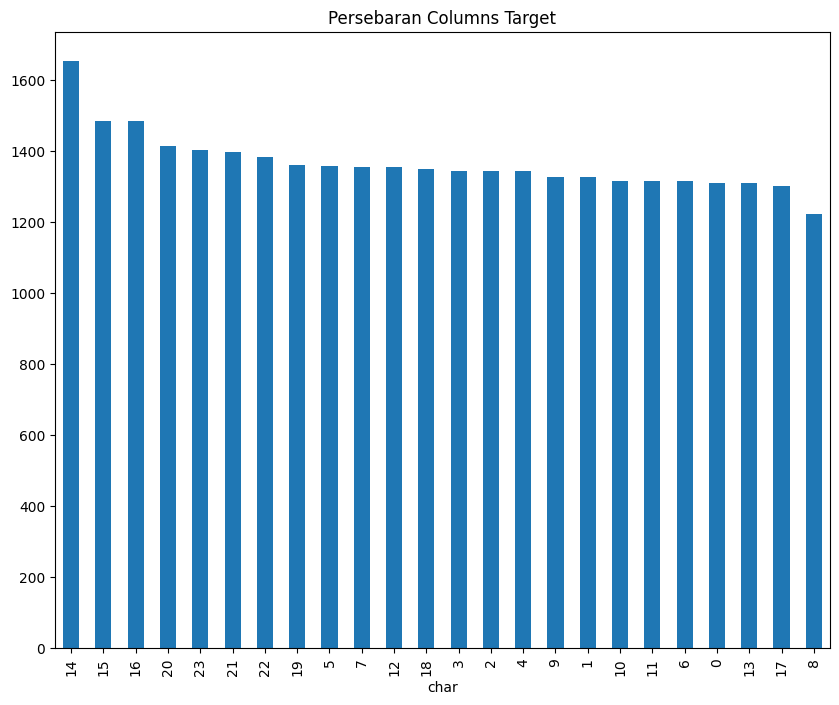

In [52]:
df_train['char'].value_counts().plot(
 kind='bar',
   figsize=(10, 8),
   )
plt.title("Persebaran Columns Target")

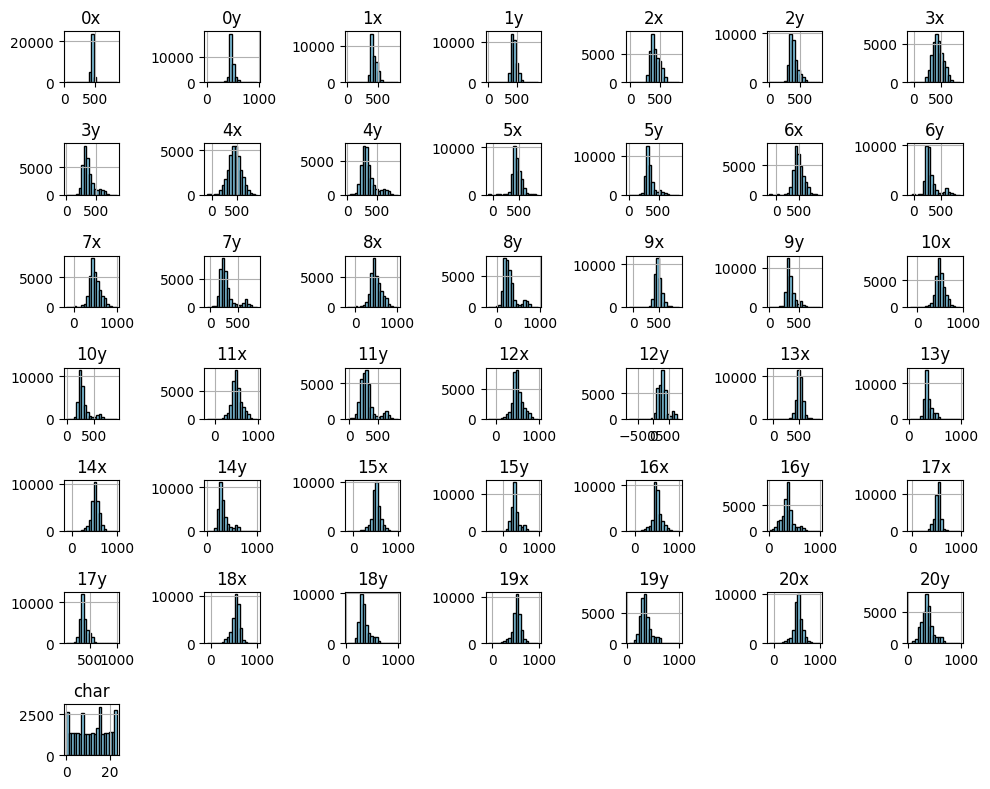

In [53]:
num = df_train.select_dtypes(include='number')
num.hist(bins = 20, edgecolor ='black', color='skyblue',figsize=(10, 8))
plt.tight_layout()

### C.2 Bivariate Analysis

<Axes: xlabel='char', ylabel='0x'>

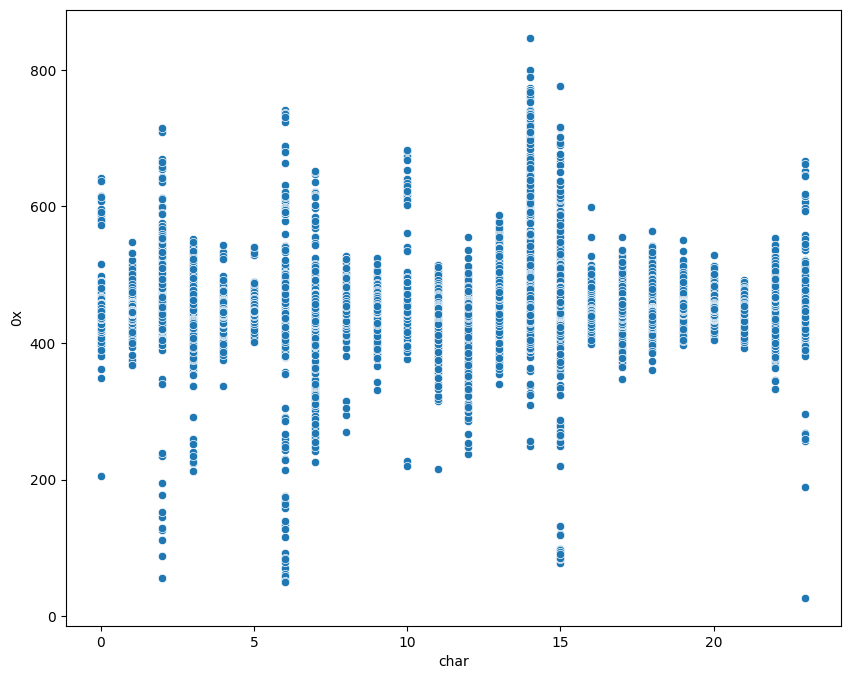

In [55]:
plt.figure(figsize=(10, 8))
sns.scatterplot(df_train, x='char', y = '0x')

<Axes: xlabel='char', ylabel='0y'>

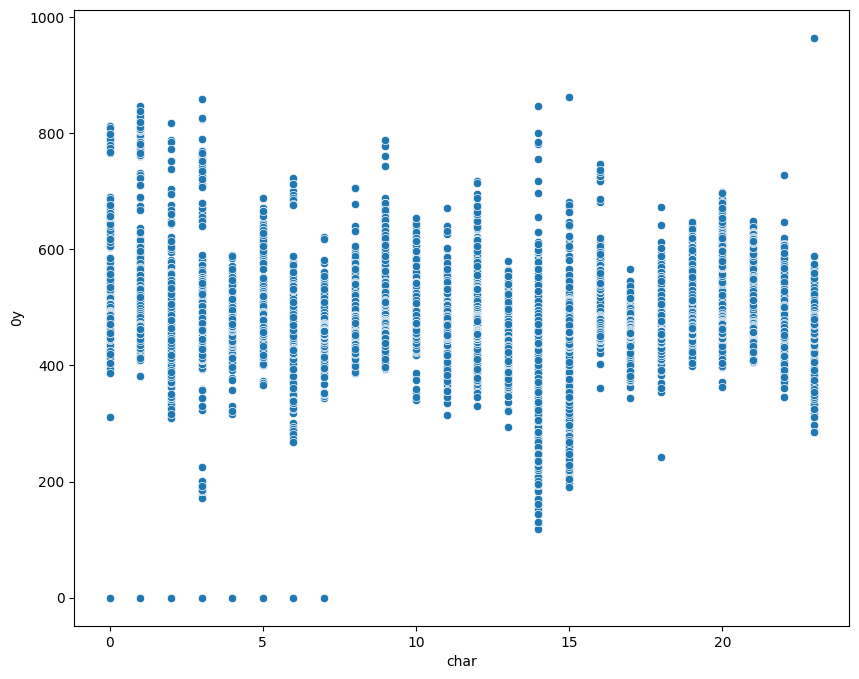

In [56]:
plt.figure(figsize=(10, 8))
sns.scatterplot(df_train, x='char', y = '0y')

<Axes: xlabel='1x', ylabel='20x'>

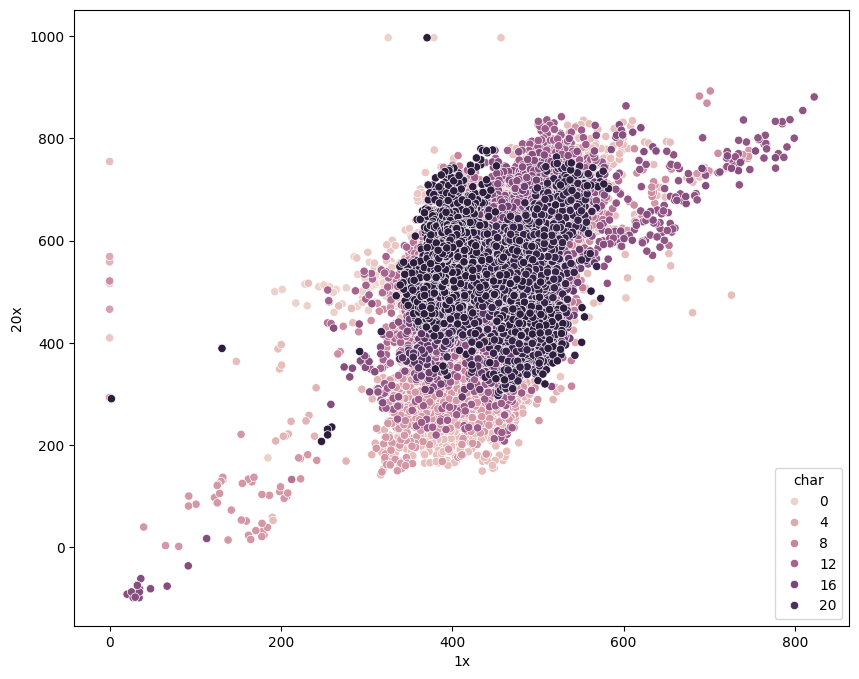

In [60]:
plt.figure(figsize=(10, 8))
sns.scatterplot(df_train, y='20x', x='1x',hue='char')

<Axes: xlabel='1y', ylabel='20y'>

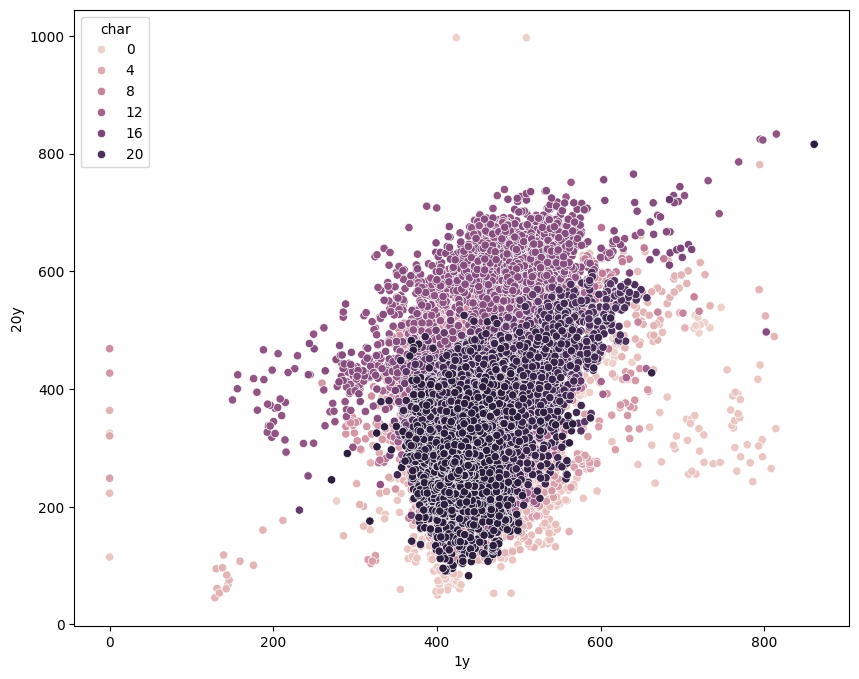

In [58]:
plt.figure(figsize=(10, 8))
sns.scatterplot(df_train, y='20y', x='1y',hue='char')

### C.3 Multivariate Analysis

<Axes: >

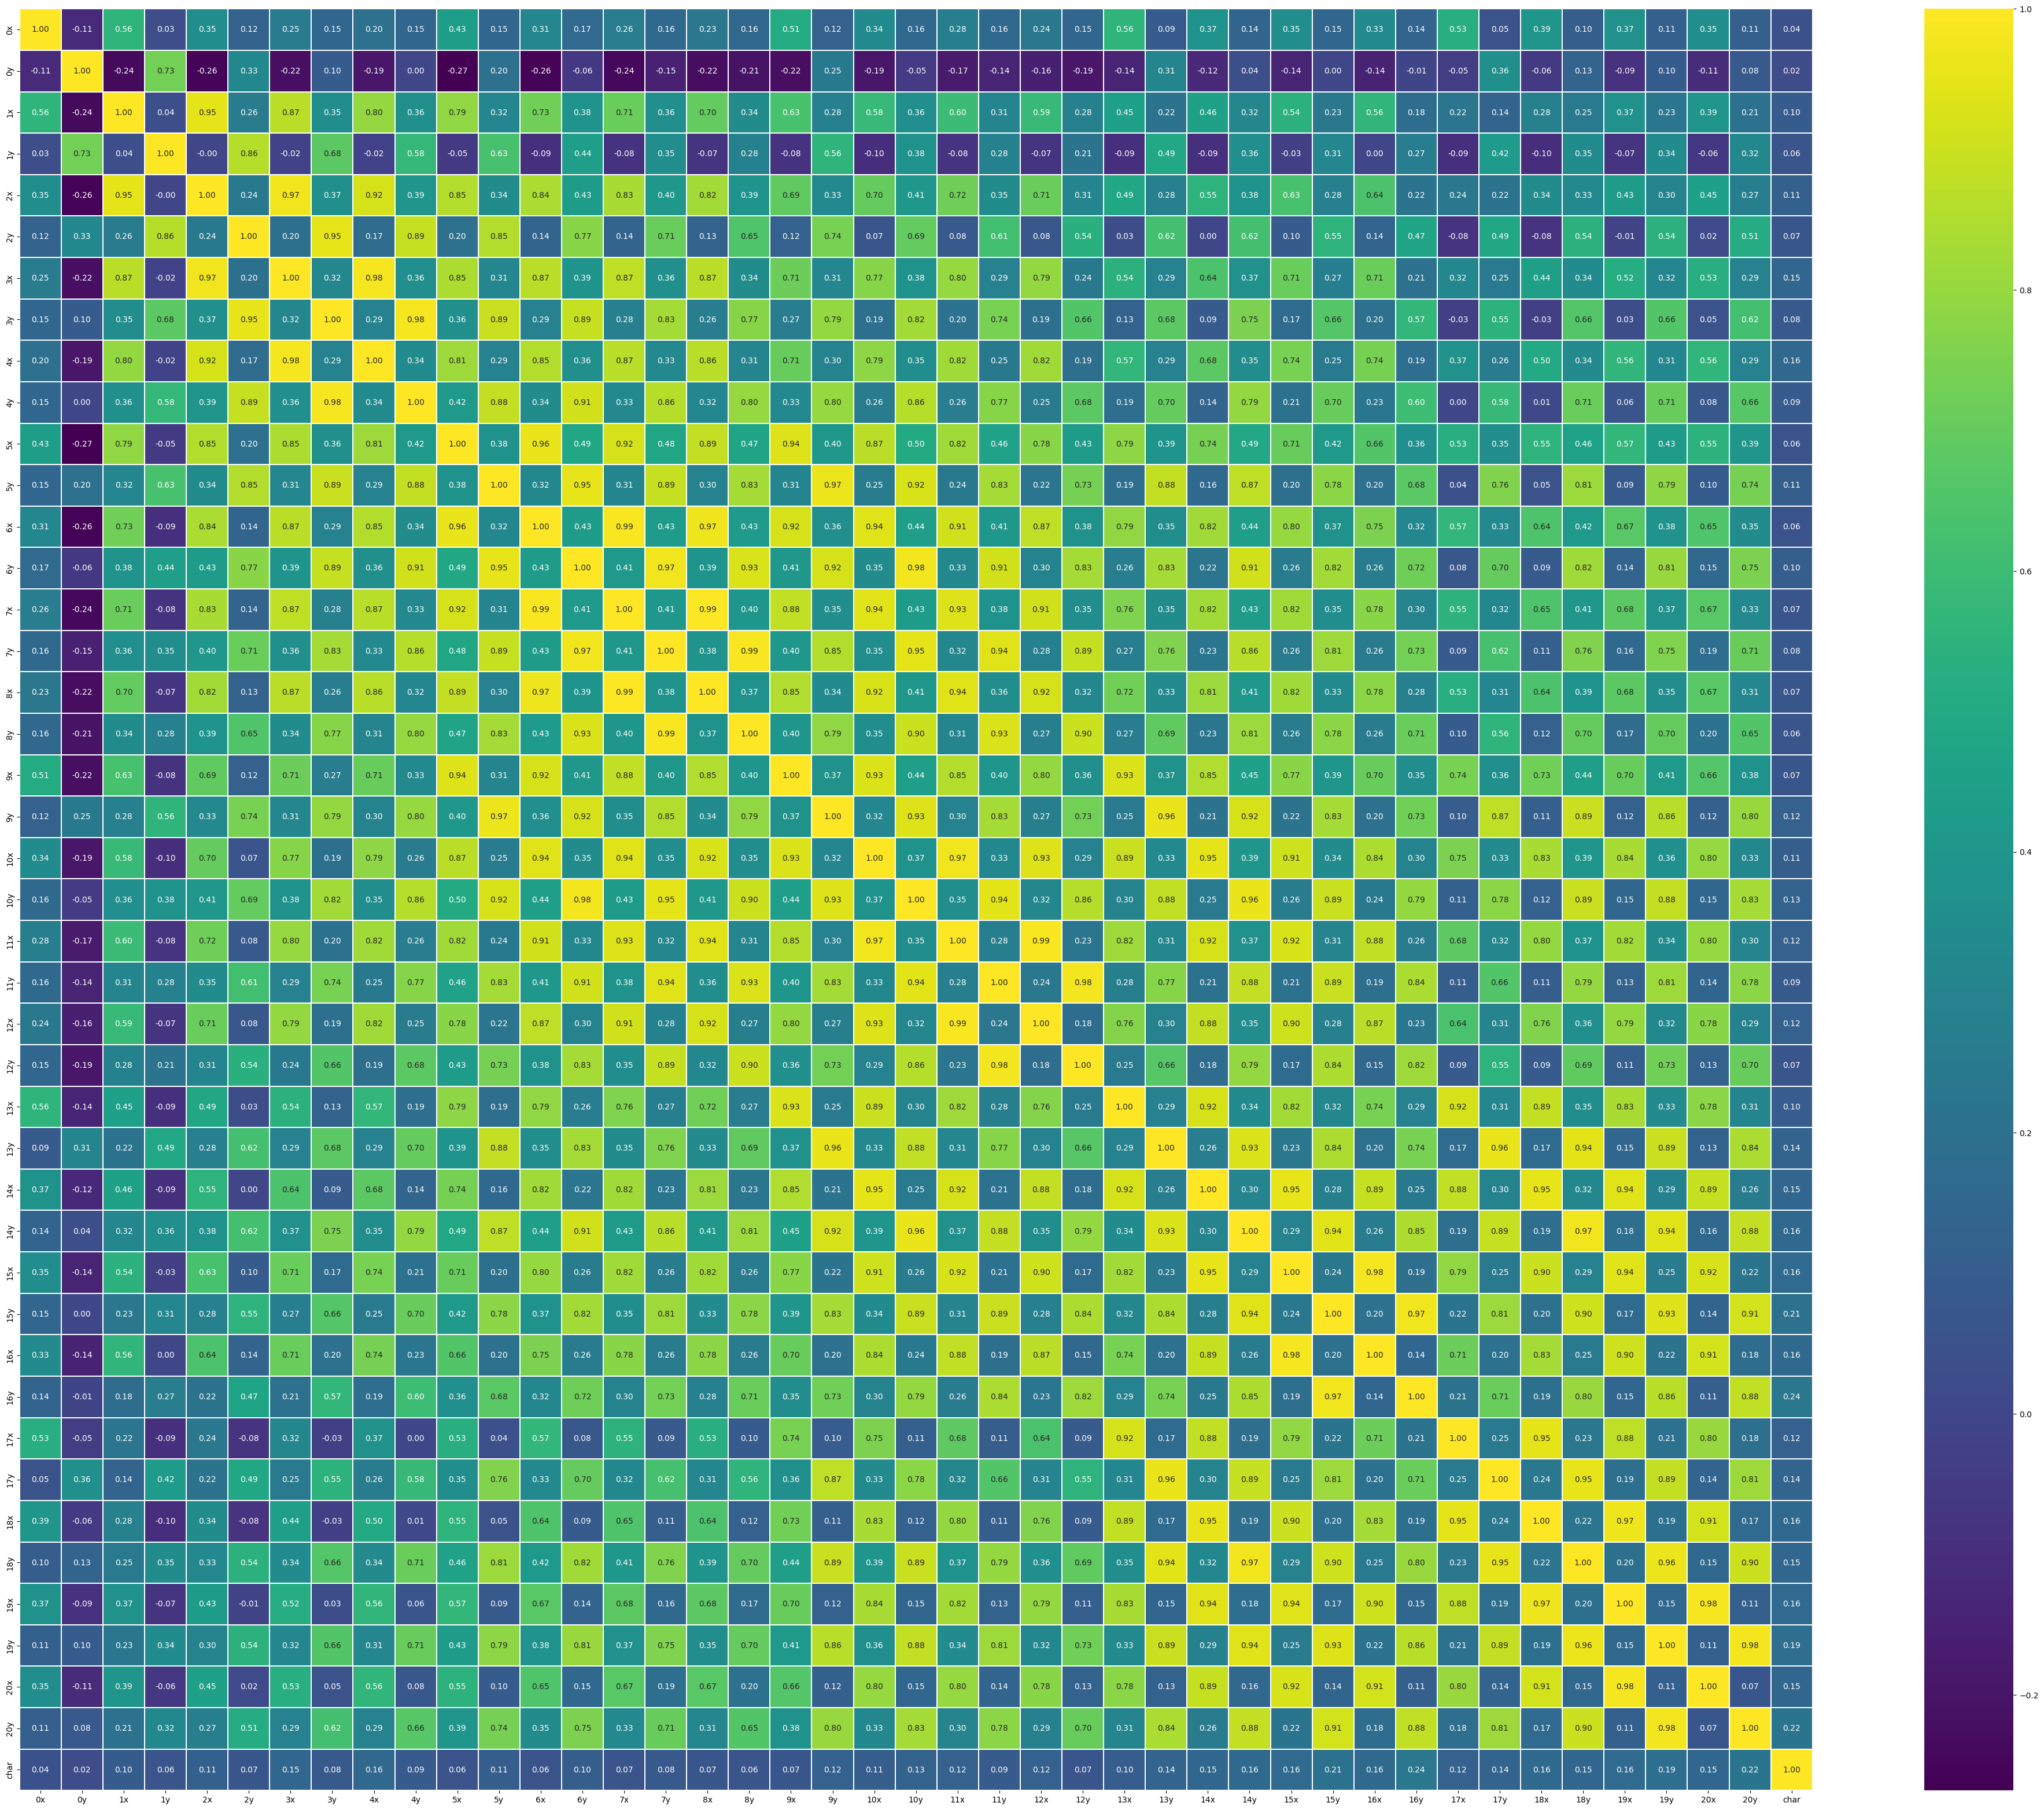

In [61]:
plt.figure(figsize=(50, 40))
sns.heatmap(df_train.corr(),
            annot = True,
            cmap = 'viridis',
            fmt = '.2f',
            linewidth = 1.1)

## D. Modelling

### D.1 Standarisasi

In [21]:
features_train = df_train.drop(columns='char')
features_test = df_test.drop(columns='char')

In [22]:
features_train = (features_train - features_train.mean(axis=0)) / features_train.std(axis=0)
features_test = (features_test - features_test.mean(axis=0)) / features_test.std(axis=0)

### D.2 Normalisasi

In [23]:
# features_train = (features_train - features_train.mean(axis=0)) / features_train.std(axis=0)
# features_test = (features_test - features_test.mean(axis=0)) / features_test.std(axis=0)

### D.3 Defining X (Features) and y (Target) Variables

In [24]:
X_train = features_train
X_test = features_test
y_train = df_train['char']
y_test = df_test['char']

# X_data = features_train
# y_data = df_train['char']

### D.4 Splitting Data Train and Data Test (80:20)

In [25]:
# def stratified_split(x_data, y_data, train_size = 0.8, random_state = 42):
#     np.random.seed(random_state)
    
#     x_train_list, x_test_list = [], []
#     y_train_list, y_test_list = [], []
    
#     for class_value in np.unique(y_data):
#         class_idx = np.where(y_data == class_value)[0]
        
#         idx = np.random.permutation(class_idx)
#         split_ratio = int(len(idx) * train_size)
        
#         x_train_list.append(x_data.iloc[idx[:split_ratio]])
#         x_test_list.append(x_data.iloc[idx[split_ratio:]])
#         y_train_list.append(y_data.iloc[idx[:split_ratio]])
#         y_test_list.append(y_data.iloc[idx[split_ratio:]])
        
#     x_train = pd.concat(x_train_list).reset_index(drop = True)
#     x_test = pd.concat(x_test_list).reset_index(drop = True)
#     y_train = pd.concat(y_train_list).reset_index(drop = True)
#     y_test = pd.concat(y_test_list).reset_index(drop = True)
    
#     return x_train, x_test, y_train, y_test
# X_train, X_test, y_train, y_test = stratified_split(X_data, y_data)

### D.5 K-Nearest Neighbors

In [26]:
class KNN:
    def __init__(self, k, p):
        self.K = k
        self.P = p
        
    def train(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def jarak(self, x1, x2):
        if self.P == 1:
            return np.sum(np.abs(x1 - x2))
        else:
            return np.sqrt(np.sum((x1 - x2) ** 2))
        
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)
    
    def _predict(self, x):
        jaraks = [self.jarak(x, x_train) for x_train in self.X_train]
        best_k = np.argsort(jaraks)[:self.K]
        label_k = [self.y_train[i] for i in best_k]
        hasil = max(set(label_k), key=label_k.count)
        return hasil

### D.6 Grid-Search (Finding Optimal K and Distance)

In [27]:
print("|   K   |   Jarak   |   Akurasi   |")
best_acc = 0
best_params = {}

for k in [3, 5, 7, 9]:
    for p in [1, 2]:
        model = KNN(k, p)
        model.train(X_train.values, y_train.values)
        pred = model.predict(X_test.values)
        acc = np.mean(pred == y_test.values)
        
        jarak = "Manhattan" if p == 1 else "Euclidean"
        print(f"|   {k}   |   {jarak}   |   {acc}   ")
        
        if acc > best_acc:
            best_acc = acc
            best_params = {'k' : k, 'p' : p}
            
            
nama_jarak = "Manhattan" if best_params['p'] == 1 else "Euclidean"
print(f"Best K: {best_params['k']} | Best Jarak: {nama_jarak} | Best Akurasi: {best_acc}")

|   K   |   Jarak   |   Akurasi   |
|   3   |   Manhattan   |   0.9214486724580937   
|   3   |   Euclidean   |   0.9238957543129818   
|   5   |   Manhattan   |   0.9156980300991068   
|   5   |   Euclidean   |   0.916676862841062   
|   7   |   Manhattan   |   0.9038296831028998   
|   7   |   Euclidean   |   0.906643827236021   
|   9   |   Manhattan   |   0.8956319588890248   
|   9   |   Euclidean   |   0.8984461030221461   
Best K: 3 | Best Jarak: Euclidean | Best Akurasi: 0.9238957543129818


### D.7 Elbow Method (Checking Optimal K)

#### Euclidean Distance

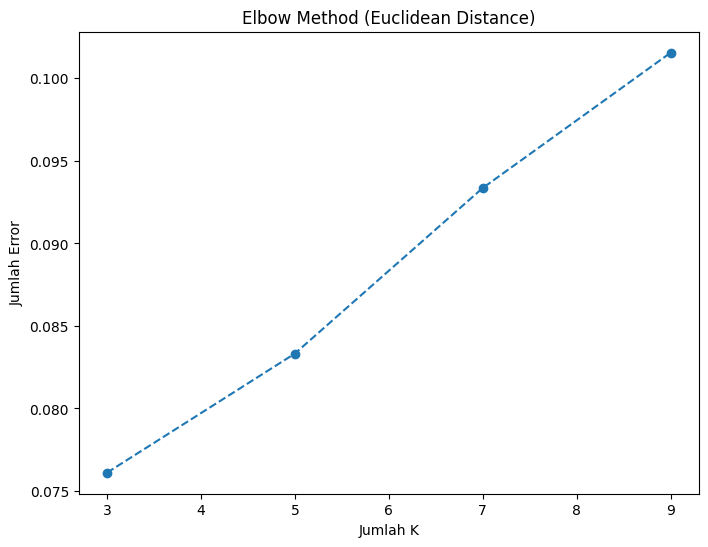

In [71]:
errors = []
range_k = [3, 5, 7, 9]

for k in range_k:
        model = KNN(k, 2)
        model.train(X_train.values, y_train.values)
        pred = model.predict(X_test.values)
        error = np.mean(pred != y_test.values)
        errors.append(error)
        
plt.figure(figsize=(8,6))
plt.plot(range_k, errors, marker='o', linestyle='--')
plt.title("Elbow Method (Euclidean Distance)")
plt.xlabel("Jumlah K")
plt.ylabel("Jumlah Error")
plt.show()

#### Manhattan Distance

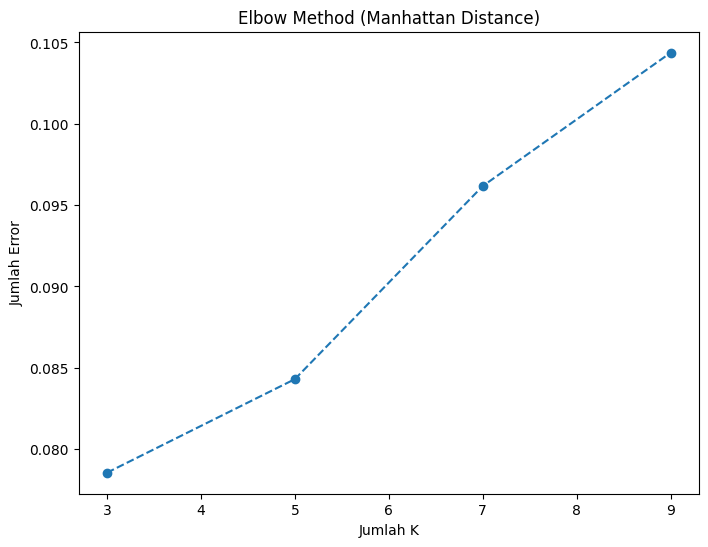

In [72]:
errors = []
range_k = [3, 5, 7, 9]

for k in range_k:
        model = KNN(k, 1)
        model.train(X_train.values, y_train.values)
        pred = model.predict(X_test.values)
        error = np.mean(pred != y_test.values)
        errors.append(error)
        
plt.figure(figsize=(8,6))
plt.plot(range_k, errors, marker='o', linestyle='--')
plt.title("Elbow Method (Manhattan Distance)")
plt.xlabel("Jumlah K")
plt.ylabel("Jumlah Error")
plt.show()

## E. Evaluasi

In [48]:
model = KNN(3, 2)
model.train(X_train.values, y_train.values)

In [49]:
y_pred_test = model.predict(X_test.values)

In [65]:
y_pred_train = model.predict(X_train.values)

### E.1 Akurasi Model

#### Akurasi Test

In [57]:
test_accuracy = np.mean(y_pred_test == y_test.values)
test_accuracy

np.float64(0.9238957543129818)

#### Akurasi Train

In [66]:
train_accuracy = np.mean(y_pred_train == y_train.values)
train_accuracy

np.float64(0.9646398389114318)

### E.2 Confusion Matrix

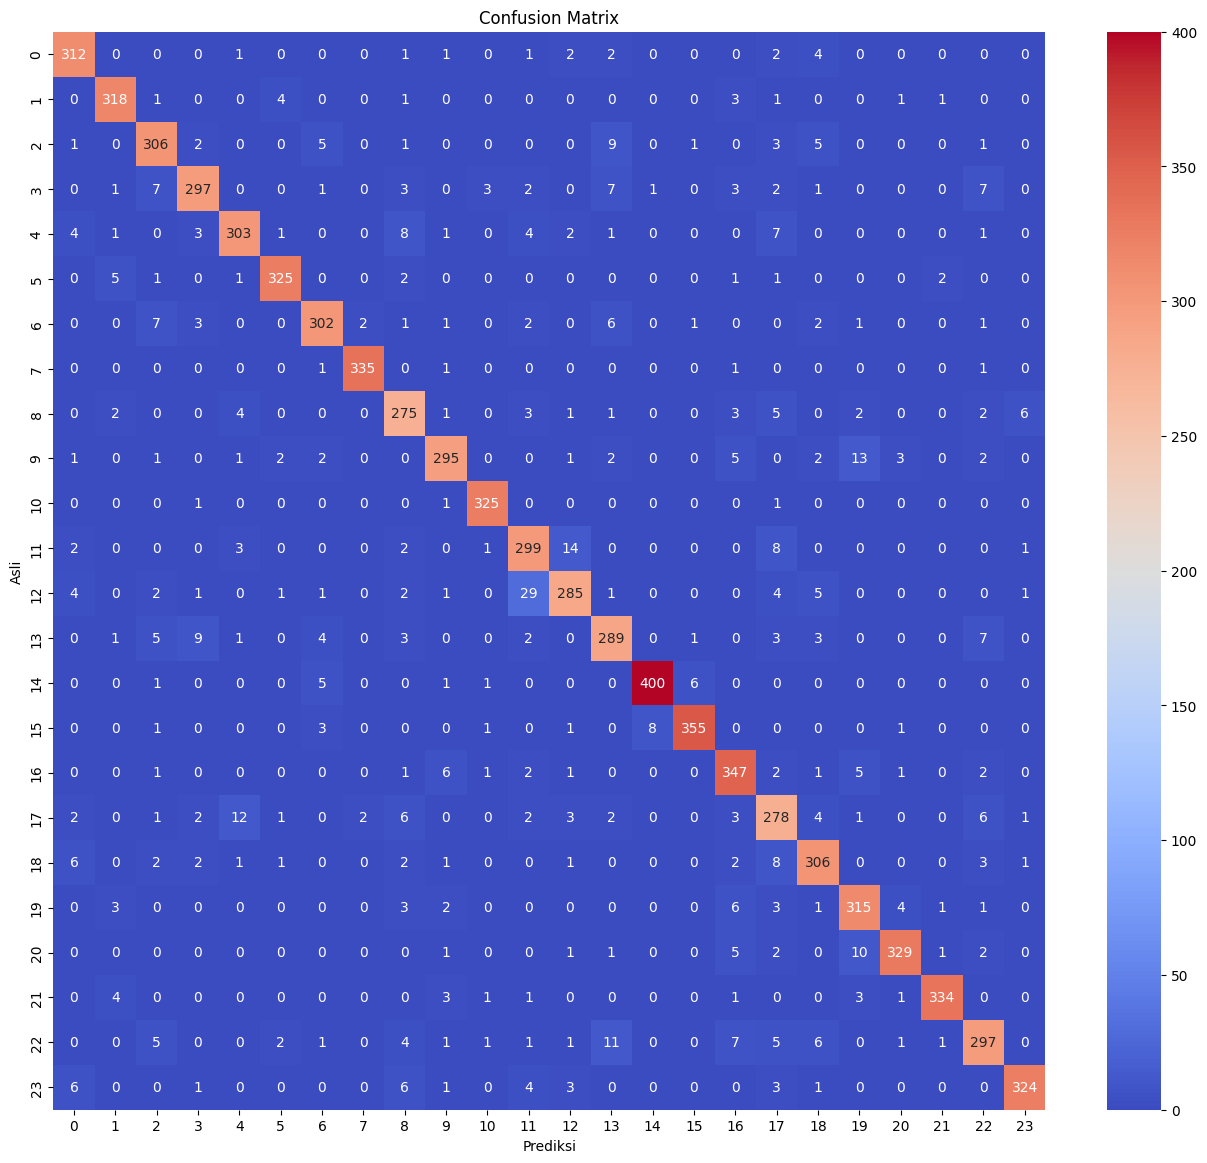

TP = 312, FP = 26, FN = 26, TN = 7821
TP = 318, FP = 17, FN = 17, TN = 7826
TP = 306, FP = 35, FN = 35, TN = 7804
TP = 297, FP = 24, FN = 24, TN = 7814
TP = 303, FP = 24, FN = 24, TN = 7813
TP = 325, FP = 12, FN = 12, TN = 7823
TP = 302, FP = 23, FN = 23, TN = 7821
TP = 335, FP = 4, FN = 4, TN = 7830
TP = 275, FP = 46, FN = 46, TN = 7822
TP = 295, FP = 23, FN = 23, TN = 7820
TP = 325, FP = 9, FN = 9, TN = 7836
TP = 299, FP = 53, FN = 53, TN = 7790
TP = 285, FP = 31, FN = 31, TN = 7805
TP = 289, FP = 43, FN = 43, TN = 7802
TP = 400, FP = 9, FN = 9, TN = 7750
TP = 355, FP = 9, FN = 9, TN = 7794
TP = 347, FP = 40, FN = 40, TN = 7763
TP = 278, FP = 60, FN = 60, TN = 7787
TP = 306, FP = 35, FN = 35, TN = 7802
TP = 315, FP = 35, FN = 35, TN = 7799
TP = 329, FP = 12, FN = 12, TN = 7809
TP = 334, FP = 6, FN = 6, TN = 7819
TP = 297, FP = 36, FN = 36, TN = 7793
TP = 324, FP = 10, FN = 10, TN = 7814


In [67]:
label_name = df_test['char'].unique()
n_classes = len(label_name)

cm = np.zeros((n_classes, n_classes), dtype=int)

for true, pred in zip(y_test.values, y_pred_test):
    cm[true][pred] += 1


TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)


plt.figure(figsize=(16,14))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d', xticklabels=label_name, yticklabels=label_name)
plt.xlabel("Prediksi")
plt.ylabel("Asli")
plt.title("Confusion Matrix")

plt.show()
for i, name in enumerate(label_name):
    print(f"TP = {TP[i]}, FP = {FP[i]}, FN = {FP[i]}, TN = {TN[i]}")
    

### E.3 Precision

In [68]:
precision = TP / (TP + FP)
precision = np.mean(precision)
precision

np.float64(0.923394224016997)

### E.4 Recall

In [69]:
recall = TP / (TP + FN)
recall = np.mean(recall)
recall

np.float64(0.9231041538257427)

### E.5 F-1 Score

In [70]:
f1 = 2 * (precision * recall) / (precision + recall)
f1 = np.mean(f1)
f1

np.float64(0.9232491661375113)

### E.6 Visualisasi Decision Boundary

In [27]:
x_mini = X_train.values[:, [0, 1]]
y_mini = y_train.values

model_vis = KNN(k=3, p=2)
model_vis.train(x_mini, y_mini)

x_min, x_max = x_mini[:, 0].min() - 0.2, x_mini[:, 0].max() +  0.2
y_min, y_max = x_mini[:, 1].min() - 0.2, x_mini[:, 1].max() +  0.2

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)

plt.figure(figsize=(10, 8))

plt.countourf(xx, yy, z, cmap ='coolwarm', alpha = 0.4)

gambar = plt.scatter(x_mini[:, 0], x_mini[:, 1], c = y_mini, cmap='coolwarm', alpha =0.4)

plt.legend(handles=gambar.legend_elements[0], labels =["A (0)", "B (1)", "C (2)"], loc='upper right')
plt.title("Decision Boundary KNN")
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'countourf'

<Figure size 1000x800 with 0 Axes>

## Kesimpulan

### Insight Analysis

#### Univariate Analysis

- Data kelas terdistribusi normal
- Data fitur terdistribusi normal namun sedikit skew ke kanan

#### Bivariate Analysis

- Setiap kordinat di dalam suatu alphabet saling berkorelasi
- Setiap alphabet memiliki titik koordinat yang berbeda

#### Multivariate Analysis

Fitur atau koordinat yang paling berkorelasi dengan class / alphabet adalah:
- 15xy
- 16xy
- 19xy
- 20xy

### Insight Modelling

#### Standarisasi / Normalisasi

- Standarisasi = Nilai tersebar di angka  + 0 -

- Normalisasi = Nilai tersebar di angka 0-1

#### Euclidean Distance / Manhattan Distance

- Euclidean = Data - Target dikuadratkan (Garis lurus)

- Manhattan = Data - Target (Garis Siku)

#### Feature Engineering

- Menggabungkan fitur 0x dan 0y menjadi 0xy, dan seterusnya